# Coding Pipeline for Bachelor's Thesis Project - Machine and Deep Learning Approaches to Heart Rate Estimation from Speech with Interpretability and Fairness Analysis

In [1]:
# Display settings 

import pandas as pd
import numpy as np

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
np.set_printoptions(suppress=True, precision=4)

## Data loading

In [2]:
import pandas as pd

df = pd.read_parquet("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/stage_4_normalised.parquet")
#metadata_df = pd.read_csv("tesdhe_metadata.csv")

df.head()

,file_name,frame_idx,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,mfcc_14,mfcc_15,mfcc_16,mfcc_17,mfcc_18,mfcc_19,mfcc_20,pitch,jitter,shimmer,mfcc_1_entropy,mfcc_1_kurtosis,mfcc_1_skewness,mfcc_2_entropy,mfcc_2_kurtosis,mfcc_2_skewness,mfcc_3_entropy,mfcc_3_kurtosis,mfcc_3_skewness,mfcc_4_entropy,mfcc_4_kurtosis,mfcc_4_skewness,mfcc_5_entropy,mfcc_5_kurtosis,mfcc_5_skewness,mfcc_6_entropy,mfcc_6_kurtosis,mfcc_6_skewness,mfcc_7_entropy,mfcc_7_kurtosis,mfcc_7_skewness,mfcc_8_entropy,mfcc_8_kurtosis,mfcc_8_skewness,mfcc_9_entropy,mfcc_9_kurtosis,mfcc_9_skewness,mfcc_10_entropy,mfcc_10_kurtosis,mfcc_10_skewness,mfcc_11_entropy,mfcc_11_kurtosis,mfcc_11_skewness,mfcc_12_entropy,mfcc_12_kurtosis,mfcc_12_skewness,mfcc_13_entropy,mfcc_13_kurtosis,mfcc_13_skewness,mfcc_14_entropy,mfcc_14_kurtosis,mfcc_14_skewness,mfcc_15_entropy,mfcc_15_kurtosis,mfcc_15_skewness,mfcc_16_entropy,mfcc_16_kurtosis,mfcc_16_skewness,mfcc_17_entropy,mfcc_17_kurtosis,mfcc_17_skewness,mfcc_18_entropy,mfcc_18_kurtosis,mfcc_18_skewness,mfcc_19_entropy,mfcc_19_kurtosis,mfcc_19_skewness,mfcc_20_entropy,mfcc_20_kurtosis,mfcc_20_skewness,pitch_entropy,pitch_kurtosis,pitch_skewness,jitter_entropy,jitter_kurtosis,jitter_skewness,shimmer_entropy,shimmer_kurtosis,shimmer_skewness,bpm
0,En001M240401A083.ogg,0,0.7849,0.2669,0.4113,0.4503,0.4612,0.4746,0.5941,0.5748,0.5732,0.5814,0.4272,0.6706,0.4873,0.5379,0.7363,0.6437,0.5866,0.5846,0.4808,0.5650,0.0000,0.0000,0.0000,0.7300,0.0607,0.4382,0.4947,0.2158,0.2300,0.6540,0.0687,0.7377,0.5344,0.2982,0.6712,0.5402,0.1092,0.4350,0.4700,0.4774,0.1290,0.7634,0.2681,0.3454,0.7946,0.2414,0.4380,0.3861,0.4982,0.1727,0.6542,0.3126,0.3020,0.7823,0.2126,0.3130,0.7473,0.1855,0.4193,0.8499,0.0158,0.3870,0.8505,0.0000,0.5763,0.8694,0.1037,0.6018,0.9416,0.0445,0.5588,0.8555,0.1667,0.6601,0.7318,0.1410,0.6695,0.0329,0.8290,0.2017,0.8375,0.0520,0.5678,0.4625,0.0918,0.3925,0.9333,0.0005,0.0579,0.8407,0.0070,0.0951,83
1,En001M240401A083.ogg,1,0.7908,0.1812,0.6004,0.4147,0.4591,0.5637,0.5078,0.5914,0.5314,0.5528,0.3849,0.6528,0.5172,0.5171,0.6419,0.4883,0.6400,0.5952,0.4046,0.5316,0.0000,0.0000,0.0000,0.7300,0.0607,0.4382,0.4947,0.2158,0.2300,0.6540,0.0687,0.7377,0.5344,0.2982,0.6712,0.5402,0.1092,0.4350,0.4700,0.4774,0.1290,0.7634,0.2681,0.3454,0.7946,0.2414,0.4380,0.3861,0.4982,0.1727,0.6542,0.3126,0.3020,0.7823,0.2126,0.3130,0.7473,0.1855,0.4193,0.8499,0.0158,0.3870,0.8505,0.0000,0.5763,0.8694,0.1037,0.6018,0.9416,0.0445,0.5588,0.8555,0.1667,0.6601,0.7318,0.1410,0.6695,0.0329,0.8290,0.2017,0.8375,0.0520,0.5678,0.4625,0.0918,0.3925,0.9333,0.0005,0.0579,0.8407,0.0070,0.0951,83
2,En001M240401A083.ogg,2,0.7807,0.1332,0.5887,0.5038,0.4605,0.5496,0.6952,0.5672,0.4645,0.5144,0.2986,0.5709,0.5506,0.5690,0.6522,0.5057,0.6197,0.5280,0.4263,0.6465,0.5646,0.0000,0.0000,0.7300,0.0607,0.4382,0.4947,0.2158,0.2300,0.6540,0.0687,0.7377,0.5344,0.2982,0.6712,0.5402,0.1092,0.4350,0.4700,0.4774,0.1290,0.7634,0.2681,0.3454,0.7946,0.2414,0.4380,0.3861,0.4982,0.1727,0.6542,0.3126,0.3020,0.7823,0.2126,0.3130,0.7473,0.1855,0.4193,0.8499,0.0158,0.3870,0.8505,0.0000,0.5763,0.8694,0.1037,0.6018,0.9416,0.0445,0.5588,0.8555,0.1667,0.6601,0.7318,0.1410,0.6695,0.0329,0.8290,0.2017,0.8375,0.0520,0.5678,0.4625,0.0918,0.3925,0.9333,0.0005,0.0579,0.8407,0.0070,0.0951,83
3,En001M240401A083.ogg,3,0.8105,0.1693,0.6339,0.4811,0.4660,0.4986,0.6460,0.5748,0.5643,0.6203,0.3689,0.5561,0.4612,0.6280,0.5815,0.4949,0.7322,0.5926,0.3445,0.6811,0.5602,0.0000,0.0000,0.7300,0.0607,0.4382,0.4947,0.2158,0.2300,0.6540,0.0687,0.7377,0.5344,0.2982,0.6712,0.5402,0.1092,0.4350,0.4700,0.4774,0.1290,0.7634,0.2681,0.3454,0.7946,0.2414,0.4380,0.3861,0.4982,0.1727,0.6542,0.3126,0.3020,0.7823,0.2126,0.3130,0.7473,0.1855,0.4193,0.8499,0.0158,0.3870,0.8505,0.0000,0.5763,0.8694,0.1037,0.6018,0.9416,0.0445,0.5588,0.8555,0.1667,0.6601,0.7318,0.1410,0.6695,0.0329,0.8290,0.2017,0.8375,0.0520,0.5678,0.4625,0.0918,0.3925,0.9333,0.0005,0.0579,0.8407,0.0070,0.0951,83
4

## Metadata exploration

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- Config ----------
DATA_PATH = "/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/tesdhe_metadata.csv"

TARGET_COL = "bpm"
SPEAKER_COL = "speaker_id"
SEX_COL = "gender"
LANG_COL = "language"
AGE_COL = "age_years"

OUTPUT_DIR = "/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/outputs/exploration"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---------- Load ----------
df = pd.read_csv(DATA_PATH)

# ---------- Basic overview ----------
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nDtypes:")
print(df.dtypes)

print("\nFirst rows:")
print(df.head())

print("\nBasic numeric summary:")
print(df.describe(include=[np.number]).T)

print("\nCategorical summary:")
for col in [SEX_COL, LANG_COL]:
    if col in df.columns:
        print(f"\nValue counts: {col}")
        print(df[col].value_counts(dropna=False))

# ---------- Speaker-level overview ----------
print("\nUnique speakers:", df[SPEAKER_COL].nunique())

samples_per_speaker = df.groupby(SPEAKER_COL).size().sort_values(ascending=False)
print("\nSamples per speaker:")
print(samples_per_speaker.describe())

samples_per_speaker.to_csv(f"{OUTPUT_DIR}/samples_per_speaker.csv")

# ---------- Missing values ----------
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print("\nMissing values:")
print(missing)

missing.to_csv(f"{OUTPUT_DIR}/missing_values.csv", header=["n_missing"])

# ---------- Save full summary ----------
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_missing": df.isna().sum(),
    "n_unique": df.nunique(dropna=False)
})
summary.to_csv(f"{OUTPUT_DIR}/dataset_summary.csv")

# ---------- Plots ----------
sns.set(style="whitegrid")

# Target distribution
plt.figure(figsize=(8, 5))
sns.histplot(df[TARGET_COL], kde=True, bins=30)
plt.title("Heart Rate Distribution")
plt.xlabel("Heart Rate (BPM)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/heart_rate_distribution.png", dpi=300)
plt.close()

# Samples per speaker
plt.figure(figsize=(10, 5))
sns.histplot(samples_per_speaker, bins=30)
plt.title("Distribution of Samples per Speaker")
plt.xlabel("Number of samples")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/samples_per_speaker_distribution.png", dpi=300)
plt.close()

# Heart rate by sex
if SEX_COL in df.columns:
    plt.figure(figsize=(7, 5))
    sns.boxplot(data=df, x=SEX_COL, y=TARGET_COL)
    plt.title("Heart Rate by Sex")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/heart_rate_by_sex.png", dpi=300)
    plt.close()

# Heart rate by language
if LANG_COL in df.columns:
    plt.figure(figsize=(7, 5))
    sns.boxplot(data=df, x=LANG_COL, y=TARGET_COL)
    plt.title("Heart Rate by Language")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/heart_rate_by_language.png", dpi=300)
    plt.close()

# Age histogram
if AGE_COL in df.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[AGE_COL], bins=20, kde=True)
    plt.title("Age Distribution")
    plt.xlabel("Age")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/age_distribution.png", dpi=300)
    plt.close()

# Correlation heatmap for a subset of numeric features
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
subset_cols = [TARGET_COL] + [c for c in numeric_cols if c != TARGET_COL][:25]

corr = df[subset_cols].corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Subset of Numeric Features)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/correlation_heatmap_subset.png", dpi=300)
plt.close()


Shape: (10034, 13)

Columns:
['file_name', 'language_code', 'language', 'speaker_id', 'gender', 'age_raw', 'age_years', 'age_months', 'question_number', 'response_type_code', 'response_type', 'bpm', 'extension']

Dtypes:
file_name               str
language_code           str
language                str
speaker_id            int64
gender                  str
age_raw               int64
age_years             int64
age_months            int64
question_number       int64
response_type_code      str
response_type           str
bpm                   int64
extension               str
dtype: object

First rows:
              file_name language_code language  speaker_id gender  age_raw  \
0  En001M240401A083.ogg            En  English           1      M     2404   
1  En001M240402A079.ogg            En  English           1      M     2404   
2  En001M240403A076.ogg            En  English           1      M     2404   
3  En001M240404A076.ogg            En  English           1      M     2404  

## Train-validation-test split

In [11]:
# =============================================================================
# Speaker-independent 70/15/15 train/validation/test split with stratification
# across language and gender. Saves speaker_id, file_name, and stratum
# alongside X/y so they can be used for grouped + stratified CV later.
# =============================================================================
import numpy as np
import pandas as pd
from pathlib import Path

# --- Configuration -----------------------------------------------------------
RANDOM_STATE = 42
TRAIN_SIZE   = 0.70
VAL_SIZE     = 0.15
TEST_SIZE    = 0.15

FEATURES_PATH = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/stage_4_normalised.parquet")
METADATA_PATH = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/tesdhe_metadata.csv")
OUTPUT_DIR    = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data")

# --- Load data ---------------------------------------------------------------
features = pd.read_parquet(FEATURES_PATH)
metadata = pd.read_csv(METADATA_PATH)

# --- Build a speaker-level table for stratification --------------------------
speakers = (
    metadata.groupby("speaker_id")
            .agg(language=("language", "first"),
                 gender=("gender", "first"),
                 bpm_mean=("bpm", "mean"))
            .reset_index()
)

# BPM median split per speaker — ensures similar target distributions
# across splits alongside language and gender.
speakers["bpm_group"] = pd.qcut(
    speakers["bpm_mean"], q=2, labels=["low", "high"], duplicates="drop"
)

# Composite label: 2 × 2 × 2 = up to 8 strata
speakers["stratum"] = (
    speakers["language"] + "_" + speakers["gender"] + "_" + speakers["bpm_group"].astype(str)
)

# Fall back to language+gender for any stratum with fewer than 2 members
# (can happen when a demographic group has very few speakers).
too_small = speakers["stratum"].value_counts()
too_small = too_small[too_small < 2].index
speakers.loc[speakers["stratum"].isin(too_small), "stratum"] = (
    speakers.loc[speakers["stratum"].isin(too_small), "language"] + "_" +
    speakers.loc[speakers["stratum"].isin(too_small), "gender"]
)

# --- Speaker-independent stratified split (tolerant of small strata) ---------
# Iterates over strata and assigns speakers proportionally.
# Singletons go to train; strata of 2 get one speaker each in train/val.
rng = np.random.default_rng(RANDOM_STATE)
train_ids, val_ids, test_ids = [], [], []

for _, grp in speakers.groupby("stratum"):
    ids = grp["speaker_id"].tolist()
    rng.shuffle(ids)
    n = len(ids)
    if n == 1:
        train_ids.extend(ids)
    elif n == 2:
        train_ids.append(ids[0])
        val_ids.append(ids[1])
    else:
        n_train = max(1, round(n * TRAIN_SIZE))
        n_val   = max(1, round(n * VAL_SIZE))
        train_ids.extend(ids[:n_train])
        val_ids.extend(ids[n_train : n_train + n_val])
        test_ids.extend(ids[n_train + n_val :])

train_speakers = speakers[speakers["speaker_id"].isin(train_ids)]
val_speakers   = speakers[speakers["speaker_id"].isin(val_ids)]
test_speakers  = speakers[speakers["speaker_id"].isin(test_ids)]

# --- Map speakers back to frame-level rows -----------------------------------
# Attach speaker_id AND the demographic attributes used for stratified CV.
features = features.merge(
    metadata[["file_name", "speaker_id"]], on="file_name", how="left"
).merge(
    speakers[["speaker_id", "language", "gender", "stratum"]],
    on="speaker_id", how="left",
)

train_mask = features["speaker_id"].isin(train_speakers["speaker_id"])
val_mask   = features["speaker_id"].isin(val_speakers["speaker_id"])
test_mask  = features["speaker_id"].isin(test_speakers["speaker_id"])

# --- Build X / y / groups sets -----------------------------------------------
# Drop identifiers and labels from X; keep them in the groups frame.
DROP_COLS  = ["file_name", "frame_idx", "bpm",
              "speaker_id", "language", "gender", "stratum"]
GROUP_COLS = ["speaker_id", "file_name", "language", "gender", "stratum"]

train_rows = features.loc[train_mask].reset_index(drop=True)
val_rows   = features.loc[val_mask].reset_index(drop=True)
test_rows  = features.loc[test_mask].reset_index(drop=True)

X_train, y_train, groups_train = (
    train_rows.drop(columns=DROP_COLS),
    train_rows["bpm"],
    train_rows[GROUP_COLS],
)
X_val, y_val, groups_val = (
    val_rows.drop(columns=DROP_COLS),
    val_rows["bpm"],
    val_rows[GROUP_COLS],
)
X_test, y_test, groups_test = (
    test_rows.drop(columns=DROP_COLS),
    test_rows["bpm"],
    test_rows[GROUP_COLS],
)

# --- Save to parquet ---------------------------------------------------------
X_train.to_parquet(OUTPUT_DIR / "X_train.parquet", index=False)
y_train.to_frame().to_parquet(OUTPUT_DIR / "y_train.parquet", index=False)
groups_train.to_parquet(OUTPUT_DIR / "groups_train.parquet", index=False)

X_val.to_parquet(OUTPUT_DIR / "X_val.parquet", index=False)
y_val.to_frame().to_parquet(OUTPUT_DIR / "y_val.parquet", index=False)
groups_val.to_parquet(OUTPUT_DIR / "groups_val.parquet", index=False)

X_test.to_parquet(OUTPUT_DIR / "X_test.parquet", index=False)
y_test.to_frame().to_parquet(OUTPUT_DIR / "y_test.parquet", index=False)
groups_test.to_parquet(OUTPUT_DIR / "groups_test.parquet", index=False)

# --- Quick sanity report -----------------------------------------------------
print(f"Speakers -> train: {len(train_speakers)}  "
      f"val: {len(val_speakers)}  test: {len(test_speakers)}")
print(f"Frames   -> train: {len(X_train)}  "
      f"val: {len(X_val)}  test: {len(X_test)}")
for col in ["language", "gender", "bpm_group"]:
    comparison = pd.concat(
        [train_speakers[col].value_counts().rename("train"),
         val_speakers[col].value_counts().rename("val"),
         test_speakers[col].value_counts().rename("test")],
        axis=1,
    ).fillna(0).astype(int)
    print(f"\nSpeakers per {col}:\n{comparison}")

Speakers -> train: 77  val: 16  test: 16
Frames   -> train: 868421  val: 194387  test: 189504

Speakers per language:
          train  val  test
language                  
English      57   12    11
Tamil        20    4     5

Speakers per gender:
        train  val  test
gender                  
M          40    8     9
F          37    8     7

Speakers per bpm_group:
           train  val  test
bpm_group                  
low           39    8     8
high          38    8     8


In [12]:
X_test.head()

,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,mfcc_14,mfcc_15,mfcc_16,mfcc_17,mfcc_18,mfcc_19,mfcc_20,pitch,jitter,shimmer,mfcc_1_entropy,mfcc_1_kurtosis,mfcc_1_skewness,mfcc_2_entropy,mfcc_2_kurtosis,mfcc_2_skewness,mfcc_3_entropy,mfcc_3_kurtosis,mfcc_3_skewness,mfcc_4_entropy,mfcc_4_kurtosis,mfcc_4_skewness,mfcc_5_entropy,mfcc_5_kurtosis,mfcc_5_skewness,mfcc_6_entropy,mfcc_6_kurtosis,mfcc_6_skewness,mfcc_7_entropy,mfcc_7_kurtosis,mfcc_7_skewness,mfcc_8_entropy,mfcc_8_kurtosis,mfcc_8_skewness,mfcc_9_entropy,mfcc_9_kurtosis,mfcc_9_skewness,mfcc_10_entropy,mfcc_10_kurtosis,mfcc_10_skewness,mfcc_11_entropy,mfcc_11_kurtosis,mfcc_11_skewness,mfcc_12_entropy,mfcc_12_kurtosis,mfcc_12_skewness,mfcc_13_entropy,mfcc_13_kurtosis,mfcc_13_skewness,mfcc_14_entropy,mfcc_14_kurtosis,mfcc_14_skewness,mfcc_15_entropy,mfcc_15_kurtosis,mfcc_15_skewness,mfcc_16_entropy,mfcc_16_kurtosis,mfcc_16_skewness,mfcc_17_entropy,mfcc_17_kurtosis,mfcc_17_skewness,mfcc_18_entropy,mfcc_18_kurtosis,mfcc_18_skewness,mfcc_19_entropy,mfcc_19_kurtosis,mfcc_19_skewness,mfcc_20_entropy,mfcc_20_kurtosis,mfcc_20_skewness,pitch_entropy,pitch_kurtosis,pitch_skewness,jitter_entropy,jitter_kurtosis,jitter_skewness,shimmer_entropy,shimmer_kurtosis,shimmer_skewness
0,0.5065,0.3259,0.5695,0.4419,0.8164,0.3668,0.7100,0.7929,0.3811,0.4452,0.4204,0.5712,0.4130,0.6312,0.5129,0.7363,0.4828,0.4640,0.5447,0.3069,0.0000,0.0000,0.0000,0.5507,0.4824,0.2640,0.5949,0.0779,0.3960,0.7111,0.2522,0.4857,0.4620,0.5088,0.6697,0.7887,0.3011,0.5876,0.6837,0.2856,0.5221,0.8328,0.0199,0.7058,0.8365,0.0914,0.5166,0.6162,0.1826,0.3644,0.4776,0.3315,0.5255,0.6561,0.0937,0.4406,0.8248,0.2264,0.4472,0.7455,0.1786,0.3497,0.7947,0.0991,0.6001,0.8385,0.1270,0.4436,0.5252,0.2460,0.5995,0.6520,0.4210,0.6370,0.6591,0.2022,0.5306,0.2623,0.5736,0.5050,0.7449,0.3016,0.8036,0.4422,0.0103,0.7035,0.1823,0.3443,0.5717,0.3306,0.5037,0.6822
1,0.5608,0.2458,0.5490,0.4370,0.7988,0.3162,0.5779,0.7602,0.4149,0.5628,0.5977,0.7618,0.5210,0.6271,0.5242,0.7525,0.3456,0.3382,0.4652,0.4619,0.0000,0.0000,0.0000,0.5507,0.4824,0.2640,0.5949,0.0779,0.3960,0.7111,0.2522,0.4857,0.4620,0.5088,0.6697,0.7887,0.3011,0.5876,0.6837,0.2856,0.5221,0.8328,0.0199,0.7058,0.8365,0.0914,0.5166,0.6162,0.1826,0.3644,0.4776,0.3315,0.5255,0.6561,0.0937,0.4406,0.8248,0.2264,0.4472,0.7455,0.1786,0.3497,0.7947,0.0991,0.6001,0.8385,0.1270,0.4436,0.5252,0.2460,0.5995,0.6520,0.4210,0.6370,0.6591,0.2022,0.5306,0.2623,0.5736,0.5050,0.7449,0.3016,0.8036,0.4422,0.0103,0.7035,0.1823,0.3443,0.5717,0.3306,0.5037,0.6822
2,0.6063,0.2630,0.5989,0.4877,0.8265,0.3445,0.7517,0.7368,0.3176,0.5164,0.5722,0.6103,0.4587,0.5718,0.4557,0.7613,0.2623,0.3752,0.5682,0.4841,0.0000,0.0000,0.0000,0.5507,0.4824,0.2640,0.5949,0.0779,0.3960,0.7111,0.2522,0.4857,0.4620,0.5088,0.6697,0.7887,0.3011,0.5876,0.6837,0.2856,0.5221,0.8328,0.0199,0.7058,0.8365,0.0914,0.5166,0.6162,0.1826,0.3644,0.4776,0.3315,0.5255,0.6561,0.0937,0.4406,0.8248,0.2264,0.4472,0.7455,0.1786,0.3497,0.7947,0.0991,0.6001,0.8385,0.1270,0.4436,0.5252,0.2460,0.5995,0.6520,0.4210,0.6370,0.6591,0.2022,0.5306,0.2623,0.5736,0.5050,0.7449,0.3016,0.8036,0.4422,0.0103,0.7035,0.1823,0.3443,0.5717,0.3306,0.5037,0.6822
3,0.6357,0.2178,0.5588,0.4758,0.8118,0.3169,0.6614,0.8044,0.4477,0.3737,0.5002,0.6633,0.3208,0.4678,0.4709,0.7005,0.2342,0.3542,0.5616,0.4924,0.0000,0.0000,0.0000,0.5507,0.4824,0.2640,0.5949,0.0779,0.3960,0.7111,0.2522,0.4857,0.4620,0.5088,0.6697,0.7887,0.3011,0.5876,0.6837,0.2856,0.5221,0.8328,0.0199,0.7058,0.8365,0.0914,0.5166,0.6162,0.1826,0.3644,0.4776,0.3315,0.5255,0.6561,0.0937,0.4406,0.8248,0.2264,0.4472,0.7455,0.1786,0.3497,0.7947,0.0991,0.6001,0.8385,0.1270,0.4436,0.5252,0.2460,0.5995,0.6520,0.4210,0.6370,0.6591,0.2022,0.5306,0.2623,0.5736,0.5050,0.7449,0.3016,0.8036,0.4422,0.0103,0.7035,0.1823,0.3443,0.5717,0.3306,0.5037,0.6822
4,0.6742,0.2637,0.5556,0.4086,0.8110,0.3941,0.7121,0.7211,0.4051,0.4777,0.5248,0.5919,0.4210,0.5530,0.4831,0.7474,0.1727,0.4354,0

            n_frames    mean     std     min     25%  median     75%      max
Train         868421 88.2000 16.5000 48.0000 77.0000 87.0000 98.0000 172.0000
Validation    194387 88.9000 21.9000 49.0000 76.0000 85.0000 96.0000 178.0000
Test          189504 87.3000 14.4000 55.0000 79.0000 85.0000 94.0000 160.0000


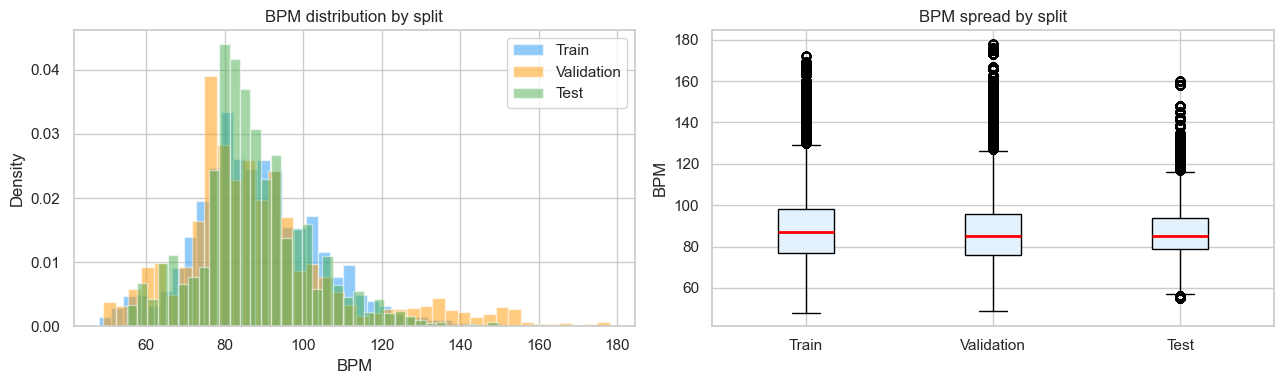

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

splits = {
    "Train":      pd.read_parquet(OUTPUT_DIR / "y_train.parquet")["bpm"],
    "Validation": pd.read_parquet(OUTPUT_DIR / "y_val.parquet")["bpm"],
    "Test":       pd.read_parquet(OUTPUT_DIR / "y_test.parquet")["bpm"],
}

# --- Summary statistics table ---
stats = pd.DataFrame({
    name: s.describe(percentiles=[0.25, 0.5, 0.75])
    for name, s in splits.items()
}).T.rename(columns={"count": "n_frames", "50%": "median"})
stats["n_frames"] = stats["n_frames"].astype(int)
print(stats[["n_frames", "mean", "std", "min", "25%", "median", "75%", "max"]].round(1).to_string())

# --- Overlapping histograms ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors = {"Train": "#2196F3", "Validation": "#FF9800", "Test": "#4CAF50"}

for name, s in splits.items():
    axes[0].hist(s, bins=40, alpha=0.5, color=colors[name], label=name, density=True)
axes[0].set_xlabel("BPM")
axes[0].set_ylabel("Density")
axes[0].set_title("BPM distribution by split")
axes[0].legend()

axes[1].boxplot(
    [s.values for s in splits.values()],
    tick_labels=list(splits.keys()),
    patch_artist=True,
    boxprops=dict(facecolor="#E3F2FD"),
    medianprops=dict(color="red", linewidth=2),
)
axes[1].set_ylabel("BPM")
axes[1].set_title("BPM spread by split")

plt.tight_layout()
plt.show()

In [14]:
y_test.head()

0    97
1    97
2    97
3    97
4    97
Name: bpm, dtype: int64

# Model training

## Baseline model - mean predictor

Before training CNN-R and XGBoost, build simple baselines so you can tell whether the more complex models truly help. This is especially important for a thesis, because a strong baseline makes the results easier to defend.

For each baseline, record:

	•	RMSE.
	•	MAE.
	•	R2.
	•	Per-fold results, not only averages.
    
This gives you a reference point for judging whether XGBoost and CNN-R are actually improving prediction.

In [2]:
# =============================================================================
# Baseline: Mean predictor
# Predicts the mean BPM of the training set for every test sample.
# Provides a reference point against which CNN-R and XGBoost will be compared.
# =============================================================================
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- Configuration -----------------------------------------------------------
RANDOM_STATE = 42
DATA_DIR = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data")

# --- Load the previously saved splits ----------------------------------------
X_train      = pd.read_parquet(DATA_DIR / "X_train.parquet")
y_train      = pd.read_parquet(DATA_DIR / "y_train.parquet").squeeze("columns")
X_test       = pd.read_parquet(DATA_DIR / "X_test.parquet")
y_test       = pd.read_parquet(DATA_DIR / "y_test.parquet").squeeze("columns")
groups_test  = pd.read_parquet(DATA_DIR / "groups_test.parquet")

# --- Fit the mean predictor --------------------------------------------------
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)

# --- Predict -----------------------------------------------------------------
y_pred = baseline.predict(X_test)

df = pd.DataFrame({
    "file_name": groups_test["file_name"].values,
    "language":  groups_test["language"].values,
    "gender":    groups_test["gender"].values,
    "y_true":    y_test.values,
    "y_pred":    y_pred,
})

# --- Helper ------------------------------------------------------------------
def _metrics(yt, yp):
    yt, yp = np.asarray(yt, float), np.asarray(yp, float)
    return {
        "n":    int(len(yt)),
        "RMSE": float(np.sqrt(mean_squared_error(yt, yp))),
        "MAE":  float(mean_absolute_error(yt, yp)),
        "R2":   float(r2_score(yt, yp)),
    }

# --- Evaluate at frame and recording level -----------------------------------
df_rec = df.groupby("file_name").agg(
    y_true=("y_true", "mean"), y_pred=("y_pred", "mean"),
    language=("language", "first"), gender=("gender", "first"),
).reset_index()

print(f"Mean BPM (training set): {y_train.mean():.2f}\n")

for level, data in [("frame", df), ("recording", df_rec)]:
    print(f"=== {level.capitalize()}-level ===")
    m = _metrics(data["y_true"], data["y_pred"])
    print(f"  Overall  : RMSE={m['RMSE']:.3f}  MAE={m['MAE']:.3f}  R2={m['R2']:.3f}  n={m['n']}")
    for col in ["language", "gender"]:
        for grp, sub in data.groupby(col):
            m = _metrics(sub["y_true"], sub["y_pred"])
            print(f"  {col}={grp:8s}: RMSE={m['RMSE']:.3f}  MAE={m['MAE']:.3f}  R2={m['R2']:.3f}  n={m['n']}")
    print()

# --- Save overall results ----------------------------------------------------
overall = _metrics(df["y_true"], df["y_pred"])
baseline_results = pd.DataFrame([{"model": "mean_predictor", **overall}])
baseline_results.to_csv("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/outputs/baseline_results.csv", index=False)

Mean BPM (training set): 88.25

=== Frame-level ===
  Overall  : RMSE=14.458  MAE=10.956  R2=-0.005  n=189504
  language=English : RMSE=14.015  MAE=10.636  R2=-0.031  n=146195
  language=Tamil   : RMSE=15.864  MAE=12.036  R2=-0.063  n=43309
  gender=F       : RMSE=16.696  MAE=12.142  R2=-0.393  n=62979
  gender=M       : RMSE=13.204  MAE=10.366  R2=-0.248  n=126525

=== Recording-level ===
  Overall  : RMSE=15.648  MAE=11.943  R2=-0.008  n=1421
  language=English : RMSE=15.176  MAE=11.687  R2=-0.042  n=1104
  language=Tamil   : RMSE=17.193  MAE=12.835  R2=-0.064  n=317
  gender=F       : RMSE=16.403  MAE=11.652  R2=-0.282  n=502
  gender=M       : RMSE=15.220  MAE=12.102  R2=-0.214  n=919



## XGBoost training and tuning

### Coarse hyperparameter tuning with RandomSearchCV

In [1]:
# =============================================================================
# XGBoost — coarse + fine hyperparameter search
#
# CV structure: 5-fold StratifiedGroupKFold on X_train (speaker-independent,
# stratified by language × gender × BPM tertile so folds have balanced target
# distributions). Scorer: recording-level RMSE.
#
# =============================================================================
import json
import numpy as np
import pandas as pd
from pathlib import Path
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, StratifiedGroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error

# --- Configuration -----------------------------------------------------------
RANDOM_STATE = 42
N_FOLDS      = 5      # inner folds for tuning
N_ITER       = 40     # coarse random combinations

DATA_DIR = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data")
OUT_DIR  = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/outputs/XGB")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Load data ---------------------------------------------------------------
X_train      = pd.read_parquet(DATA_DIR / "X_train.parquet").reset_index(drop=True)
y_train      = pd.read_parquet(DATA_DIR / "y_train.parquet").squeeze("columns").reset_index(drop=True)
groups_train = pd.read_parquet(DATA_DIR / "groups_train.parquet").reset_index(drop=True)

X_val      = pd.read_parquet(DATA_DIR / "X_val.parquet")
y_val      = pd.read_parquet(DATA_DIR / "y_val.parquet").squeeze("columns")
groups_val = pd.read_parquet(DATA_DIR / "groups_val.parquet")

X_test      = pd.read_parquet(DATA_DIR / "X_test.parquet")
y_test      = pd.read_parquet(DATA_DIR / "y_test.parquet").squeeze("columns")
groups_test = pd.read_parquet(DATA_DIR / "groups_test.parquet")

# --- Build strata: language × gender × BPM tertile --------------------------
bpm_tertile = pd.qcut(
    y_train, q=3, labels=["low", "mid", "high"], duplicates="drop"
).astype(str)
groups_train["bpm_tertile"] = bpm_tertile
groups_train["cv_stratum"]  = (
    groups_train["language"] + "_" +
    groups_train["gender"]   + "_" +
    groups_train["bpm_tertile"]
)

# --- Recording-level RMSE scorer (row index → file_name lookup) -------------
ROW_TO_FILE = groups_train["file_name"].values

def _recording_rmse(estimator, X, y_true):
    y_pred     = estimator.predict(X)
    row_pos    = y_true.index.to_numpy() if hasattr(y_true, "index") else np.arange(len(y_true))
    file_names = ROW_TO_FILE[row_pos]
    rec = (pd.DataFrame({"f": file_names, "yt": np.asarray(y_true), "yp": y_pred})
             .groupby("f")[["yt", "yp"]].mean())
    return -float(np.sqrt(mean_squared_error(rec["yt"], rec["yp"])))

# --- CV splits ---------------------------------------------------------------
sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_splits = list(
    sgkf.split(
        X_train,
        y=groups_train["cv_stratum"].values,
        groups=groups_train["speaker_id"].values,
    )
)

print("=== CV fold sanity check ===")
for i, (tr, va) in enumerate(cv_splits, 1):
    tr_spk  = set(groups_train.iloc[tr]["speaker_id"])
    va_spk  = set(groups_train.iloc[va]["speaker_id"])
    bpm_d   = groups_train.iloc[va]["bpm_tertile"].value_counts().to_dict()
    print(f"  Fold {i}: train={len(tr_spk)} spk  val={len(va_spk)} spk  "
          f"overlap={len(tr_spk & va_spk)}  BPM dist={bpm_d}")

# --- Base estimator ----------------------------------------------------------
xgb_base = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=1,
)

# --- Stage 1: Coarse random search ------------------------------------------
COARSE_GRID = {
    "n_estimators":     [200, 400, 600, 800, 1000],
    "max_depth":        [3, 5, 7, 9, 11],
    "learning_rate":    [0.01, 0.03, 0.05, 0.1, 0.2],
    "subsample":        [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "reg_alpha":        [0, 0.1, 1.0],
    "reg_lambda":       [1, 5, 10],
}

coarse = RandomizedSearchCV(
    xgb_base, COARSE_GRID, n_iter=N_ITER, scoring=_recording_rmse,
    cv=cv_splits, n_jobs=-1, verbose=1, random_state=RANDOM_STATE, refit=False,
)
coarse.fit(X_train, y_train)
best_coarse = coarse.best_params_
print(f"\nCoarse best recording RMSE (CV): {-coarse.best_score_:.3f} bpm")
print(f"Coarse best params: {best_coarse}")

# --- Stage 2: Fine grid search around the coarse winner ---------------------
def _neighbours(value, candidates):
    c = sorted(set(candidates))
    i = c.index(value)
    return c[max(0, i - 2) : min(len(c), i + 3)]

fine_grid = {
    "n_estimators":     _neighbours(best_coarse["n_estimators"],     COARSE_GRID["n_estimators"]),
    "max_depth":        _neighbours(best_coarse["max_depth"],         COARSE_GRID["max_depth"]),
    "learning_rate":    _neighbours(best_coarse["learning_rate"],     COARSE_GRID["learning_rate"]),
    "subsample":        [best_coarse["subsample"]],
    "colsample_bytree": [best_coarse["colsample_bytree"]],
    "min_child_weight": [best_coarse["min_child_weight"]],
    "reg_alpha":        [best_coarse["reg_alpha"]],
    "reg_lambda":       [best_coarse["reg_lambda"]],
}

fine = GridSearchCV(
    xgb_base, fine_grid, scoring=_recording_rmse,
    cv=cv_splits, n_jobs=-1, verbose=1, refit=True,
)
fine.fit(X_train, y_train)
best_params = fine.best_params_
best_model  = fine.best_estimator_

print(f"\nFine best recording RMSE (CV): {-fine.best_score_:.3f} bpm")
print(f"Fine best params: {best_params}")

# --- Helper: metrics dict ----------------------------------------------------
def _metrics(yt, yp):
    yt, yp = np.asarray(yt, float), np.asarray(yp, float)
    if len(yt) < 2:
        return {"n": int(len(yt)), "RMSE": float("nan"), "MAE": float("nan")}
    return {
        "n":    int(len(yt)),
        "RMSE": float(np.sqrt(mean_squared_error(yt, yp))),
        "MAE":  float(mean_absolute_error(yt, yp)),
    }

# --- Validation + test set evaluation (frame + recording) -------------------
val_metrics  = {}
test_metrics = {}

for tag, X, y_true, groups in [
    ("val",  X_val,  y_val,  groups_val),
    ("test", X_test, y_test, groups_test),
]:
    y_pred = best_model.predict(X)
    df_frame = pd.DataFrame({
        "file_name": groups["file_name"].values,
        "language":  groups["language"].values,
        "gender":    groups["gender"].values,
        "y_true":    y_true.values,
        "y_pred":    y_pred,
    })
    df_rec = df_frame.groupby("file_name").agg(
        y_true=("y_true","mean"), y_pred=("y_pred","mean"),
        language=("language","first"), gender=("gender","first")
    ).reset_index()
    result = {}
    for lvl, df in [("frame", df_frame), ("recording", df_rec)]:
        result[lvl] = {"overall": _metrics(df["y_true"].values, df["y_pred"].values)}
        for col in ["language", "gender"]:
            result[lvl][col] = {
                str(lv): _metrics(g["y_true"].values, g["y_pred"].values)
                for lv, g in df.groupby(col)
            }
    if tag == "val":
        val_metrics = result
    else:
        test_metrics = result

print("\n=== Validation set ===")
for lvl in ["frame", "recording"]:
    m = val_metrics[lvl]["overall"]
    print(f"  {lvl:10s}: RMSE={m['RMSE']:.3f}  MAE={m['MAE']:.3f}  n={m['n']}")

print("\n=== Test set ===")
for lvl in ["frame", "recording"]:
    m = test_metrics[lvl]["overall"]
    print(f"  {lvl:10s}: RMSE={m['RMSE']:.3f}  MAE={m['MAE']:.3f}  n={m['n']}")

# --- Save -------------------------------------------------------------------
best_model.save_model(OUT_DIR / "xgb_best.json")
with open(OUT_DIR / "xgb_best_params.json", "w") as fh:
    json.dump(best_params, fh, indent=2, default=str)

print(f"\nModel + params saved to {OUT_DIR}")


=== CV fold sanity check ===
  Fold 1: train=62 spk  val=15 spk  overlap=0  BPM dist={'mid': 62009, 'low': 59591, 'high': 49987}
  Fold 2: train=62 spk  val=15 spk  overlap=0  BPM dist={'mid': 60797, 'low': 58115, 'high': 51804}
  Fold 3: train=62 spk  val=15 spk  overlap=0  BPM dist={'high': 63822, 'mid': 56542, 'low': 56311}
  Fold 4: train=59 spk  val=18 spk  overlap=0  BPM dist={'high': 66948, 'mid': 66340, 'low': 52051}
  Fold 5: train=63 spk  val=14 spk  overlap=0  BPM dist={'low': 63488, 'high': 54812, 'mid': 45804}
Fitting 5 folds for each of 40 candidates, totalling 200 fits


/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/Thesis.env/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Coarse best recording RMSE (CV): 16.760 bpm
Coarse best params: {'subsample': 0.8, 'reg_lambda': 10, 'reg_alpha': 1.0, 'n_estimators': 400, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
Fitting 5 folds for each of 60 candidates, totalling 300 fits

Fine best recording RMSE (CV): 16.754 bpm
Fine best params: {'colsample_bytree': 0.6, 'learning_rate': 0.01, 'max_depth': 7, 'min_child_weight': 3, 'n_estimators': 600, 'reg_alpha': 1.0, 'reg_lambda': 10, 'subsample': 0.8}

=== Validation set ===
  frame     : RMSE=21.523  MAE=15.998  n=194387
  recording : RMSE=21.774  MAE=16.092  n=1588

=== Test set ===
  frame     : RMSE=15.095  MAE=11.328  n=189504
  recording : RMSE=15.994  MAE=11.967  n=1421

Model + params saved to /Users/patrycjamichniewska/Uni/Year 3/Thesis_local/outputs/XGB


### XGBoost — 10-fold CV evaluation with best hyperparameters

Runs 10-fold speaker-independent CV (stratified by language × gender × BPM tertile)
using the best model found above. Reports recording-level RMSE / MAE / R² per fold
and per subgroup (gender, language, BPM range). Produces scatter, residual,
per-fold, and feature importance plots.

Fold  1 | Frame RMSE=19.405  MAE=15.964  | Recording RMSE=17.804  MAE=13.781  n=724
Fold  2 | Frame RMSE=14.374  MAE=11.350  | Recording RMSE=15.795  MAE=12.556  n=720
Fold  3 | Frame RMSE=15.669  MAE=12.626  | Recording RMSE=16.129  MAE=12.730  n=612
Fold  4 | Frame RMSE=16.213  MAE=12.651  | Recording RMSE=17.580  MAE=13.625  n=575
Fold  5 | Frame RMSE=16.949  MAE=13.335  | Recording RMSE=18.275  MAE=14.504  n=649
Fold  6 | Frame RMSE=18.574  MAE=14.680  | Recording RMSE=19.011  MAE=14.915  n=772
Fold  7 | Frame RMSE=14.505  MAE=11.409  | Recording RMSE=15.415  MAE=12.044  n=780
Fold  8 | Frame RMSE=13.538  MAE=10.525  | Recording RMSE=14.392  MAE=11.194  n=761
Fold  9 | Frame RMSE=14.743  MAE=11.071  | Recording RMSE=15.018  MAE=11.192  n=780
Fold 10 | Frame RMSE=16.366  MAE=12.766  | Recording RMSE=17.594  MAE=13.708  n=652

=== Frame-level CV summary (mean ± SD) ===
                       RMSE            MAE             R2       
                       mean    std    mean    std  

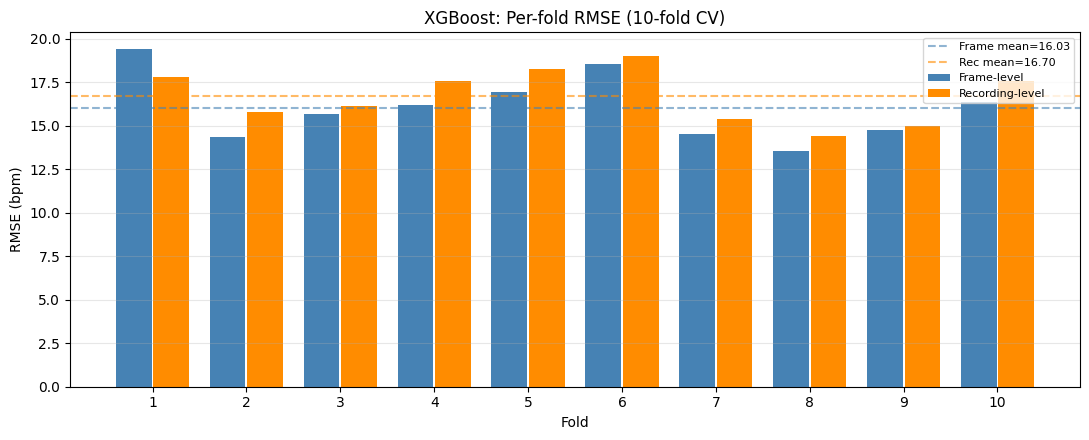

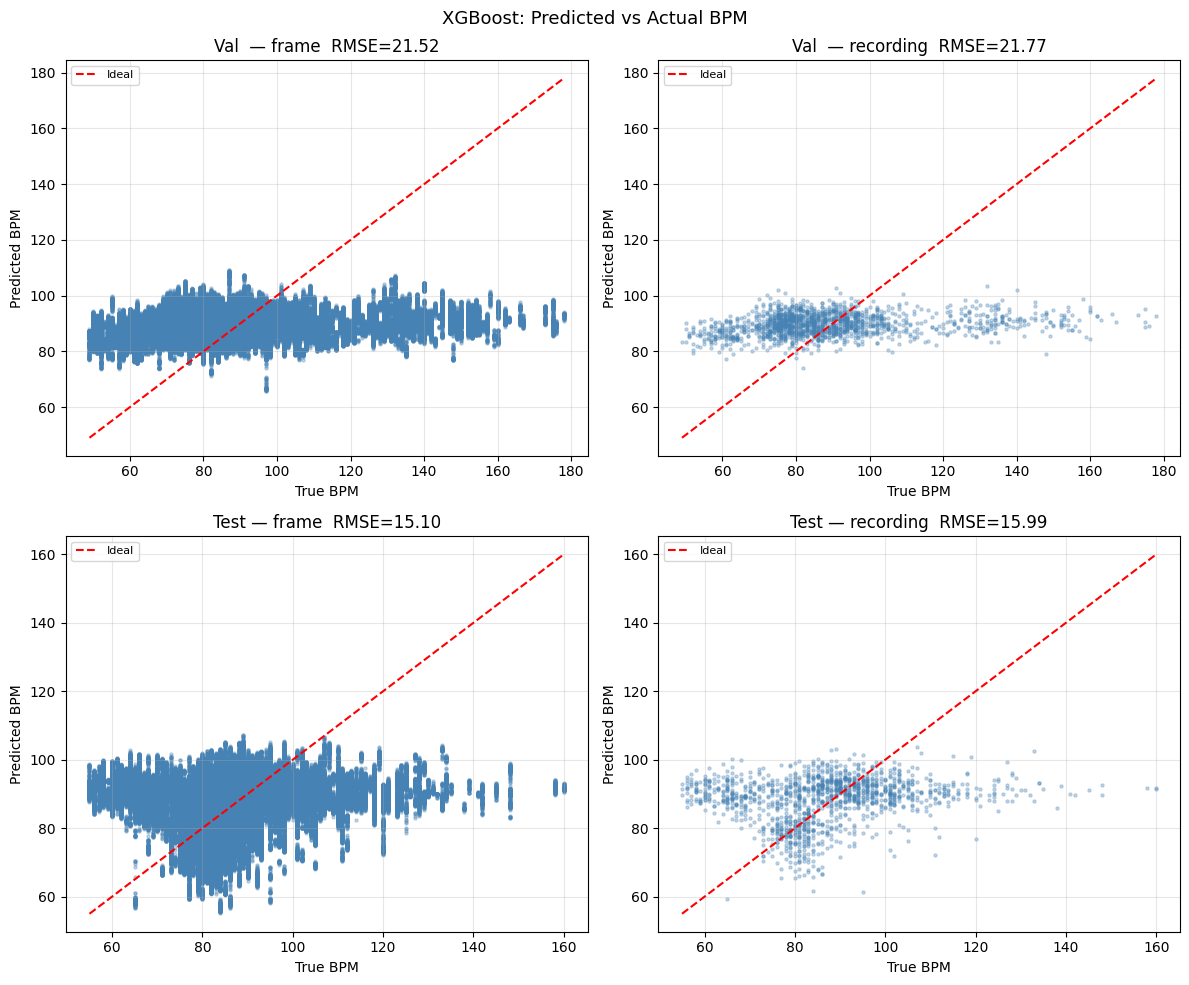

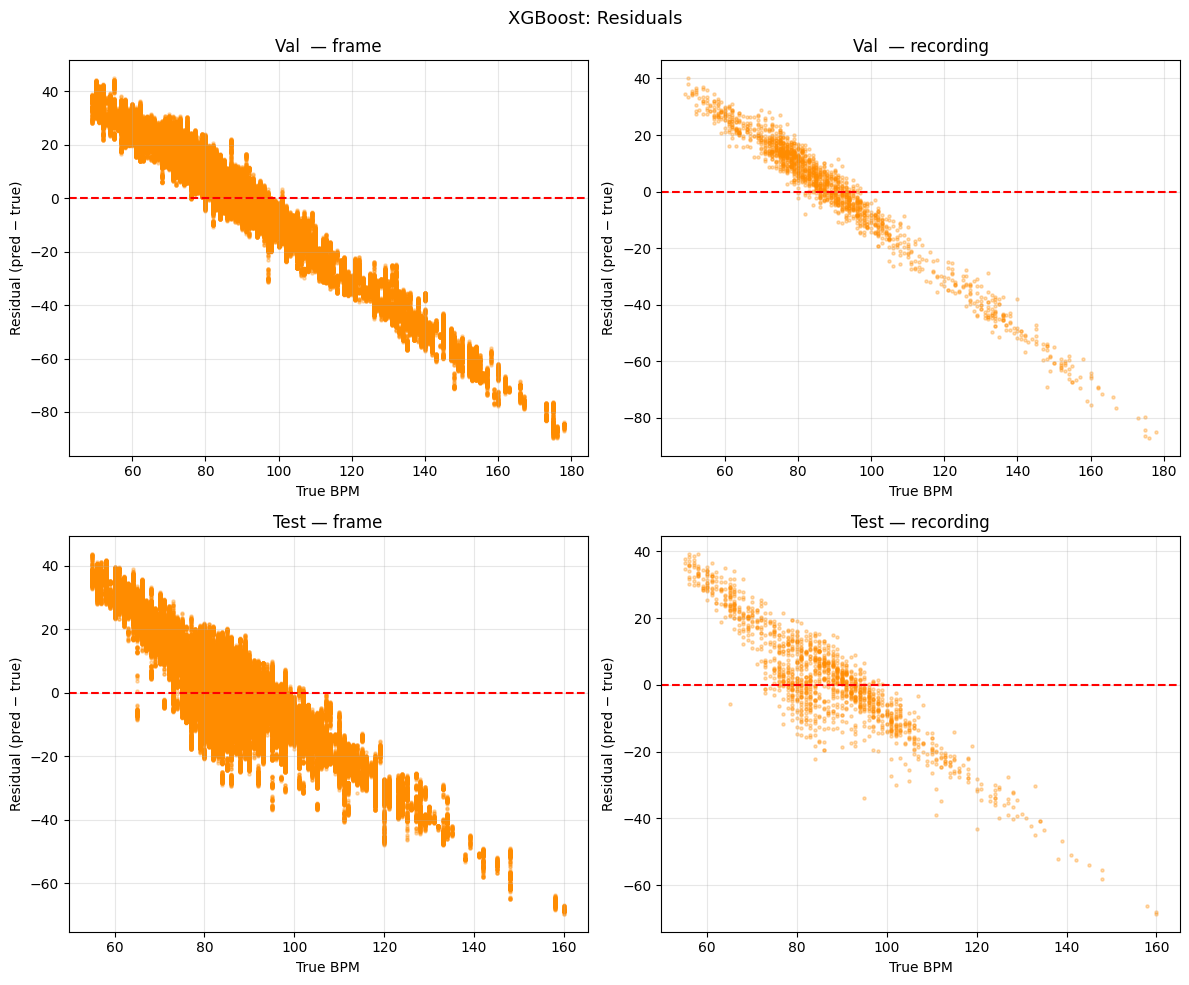

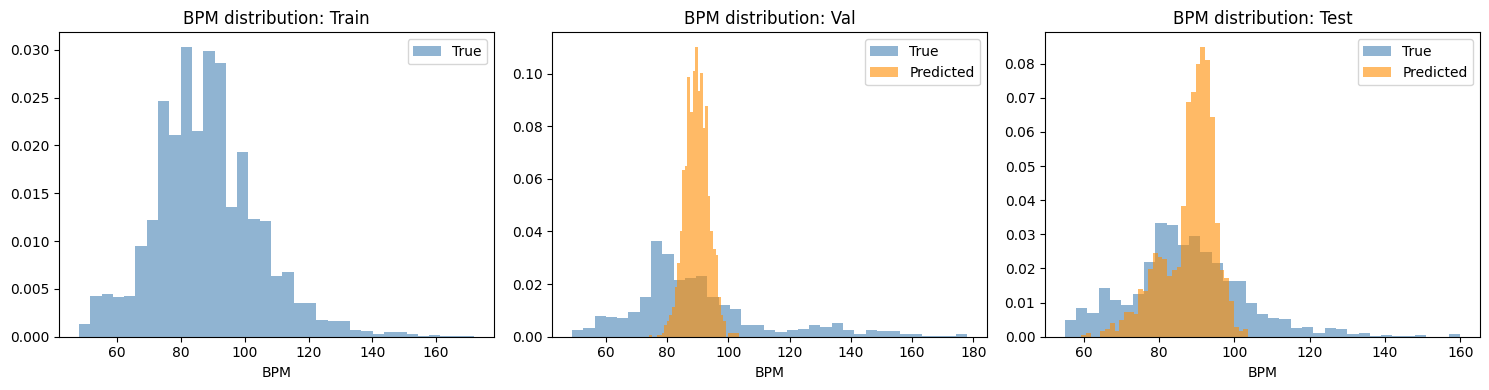

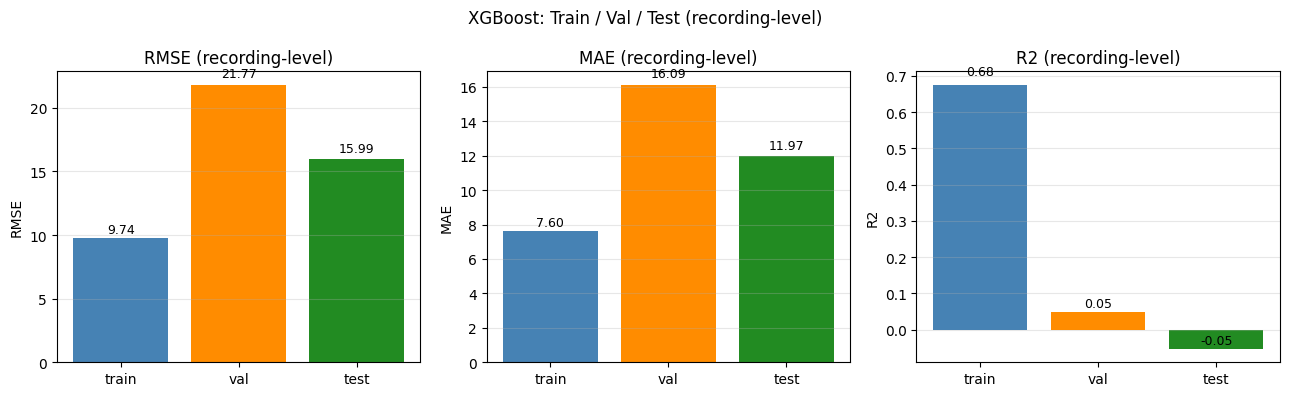

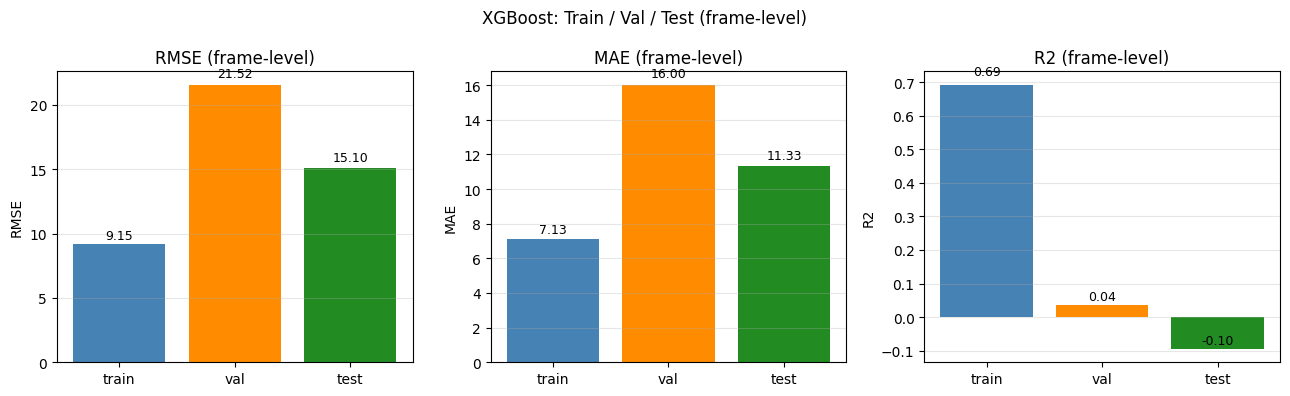

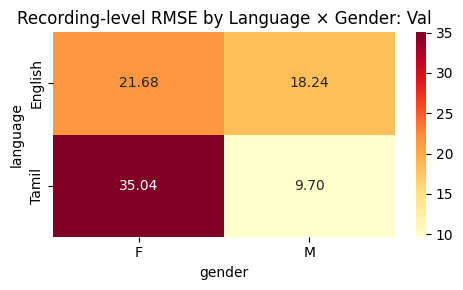

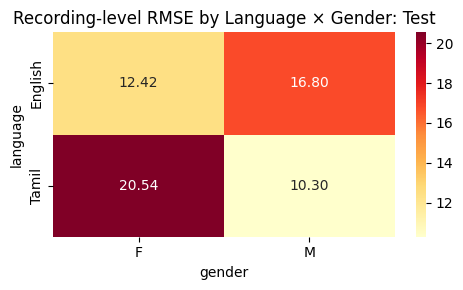

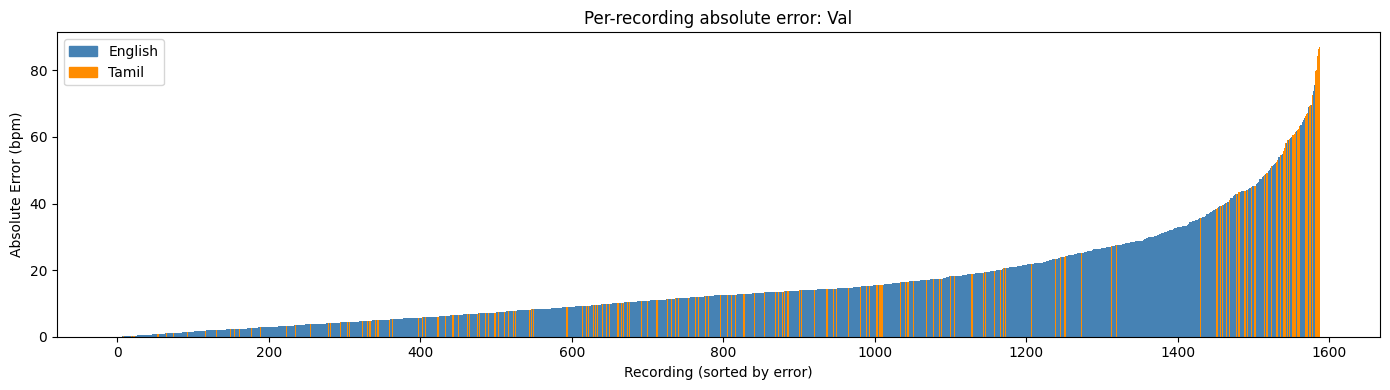

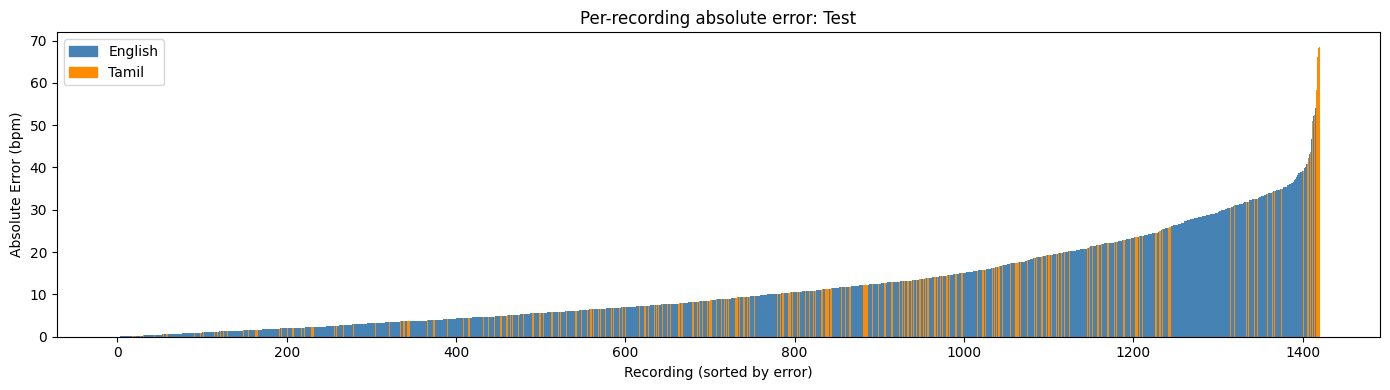

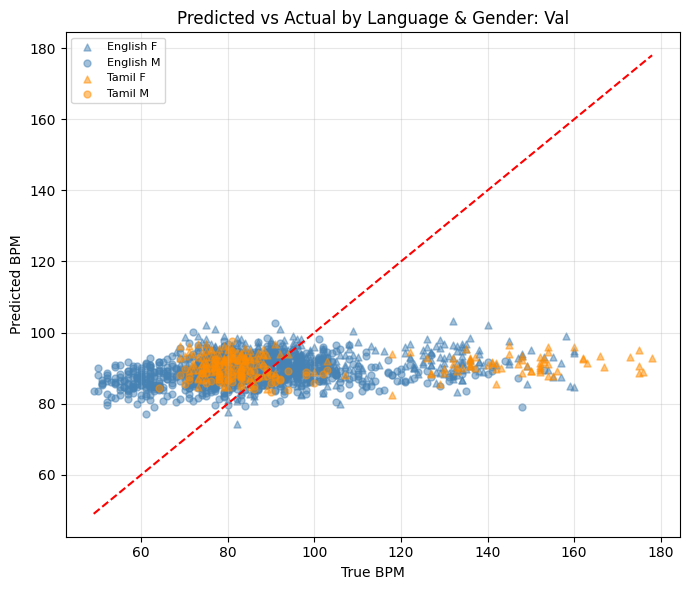

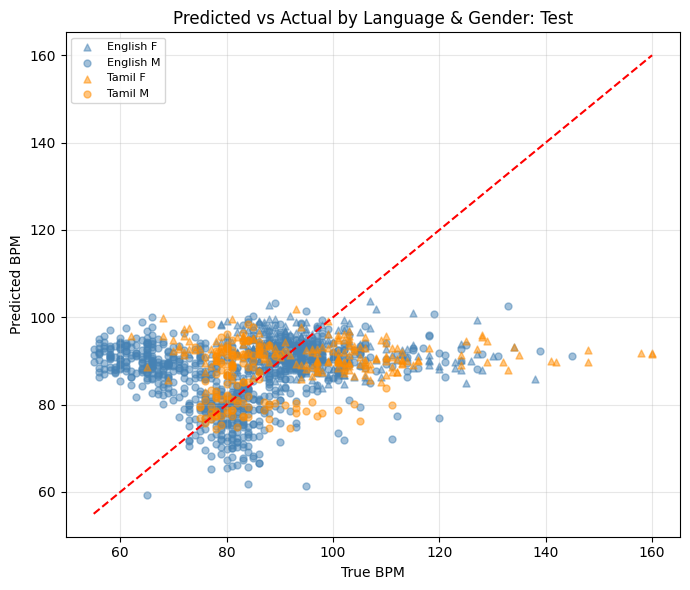

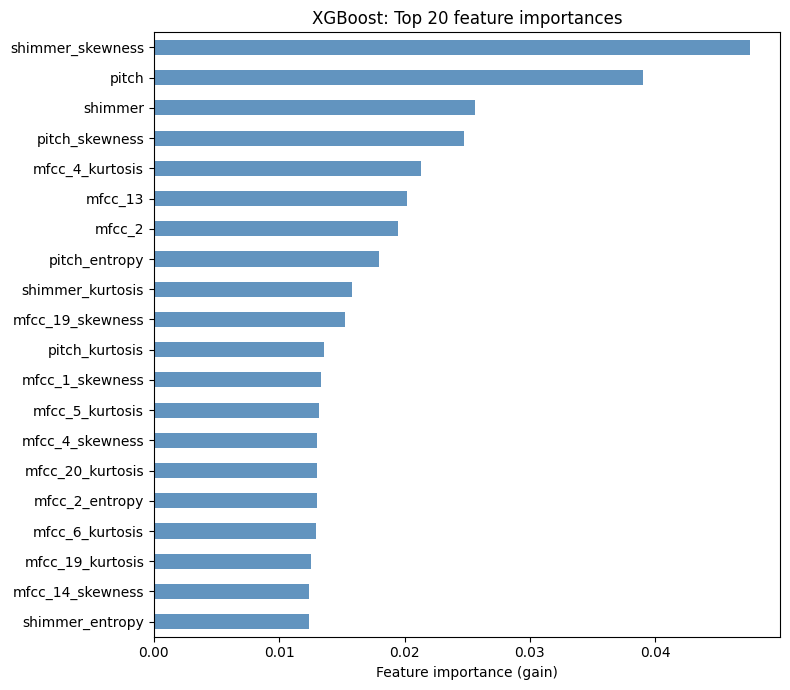

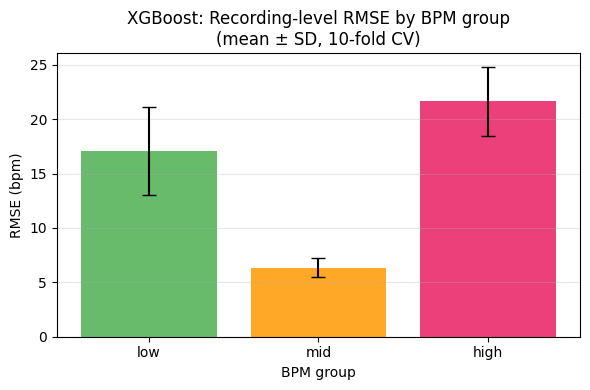


All metrics and plots saved to /Users/patrycjamichniewska/Uni/Year 3/Thesis_local/outputs/XGB


In [2]:
# =============================================================================
# XGBoost — 10-fold CV evaluation + train/val/test reporting
#
# Mirrors the CNN training cell: frame + recording level metrics,
# overall and per language/gender/BPM-group, same plot suite.
# Outputs go to outputs/XGB/.
# =============================================================================
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from xgboost import XGBRegressor
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- Configuration -----------------------------------------------------------
RANDOM_STATE = 42
N_FOLDS      = 10

DATA_DIR = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data")
OUT_DIR  = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/outputs/XGB")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Load data ---------------------------------------------------------------
X_train      = pd.read_parquet(DATA_DIR / "X_train.parquet").reset_index(drop=True)
y_train      = pd.read_parquet(DATA_DIR / "y_train.parquet").squeeze("columns").reset_index(drop=True)
groups_train = pd.read_parquet(DATA_DIR / "groups_train.parquet").reset_index(drop=True)

X_val        = pd.read_parquet(DATA_DIR / "X_val.parquet").reset_index(drop=True)
y_val        = pd.read_parquet(DATA_DIR / "y_val.parquet").squeeze("columns").reset_index(drop=True)
groups_val   = pd.read_parquet(DATA_DIR / "groups_val.parquet").reset_index(drop=True)

X_test       = pd.read_parquet(DATA_DIR / "X_test.parquet").reset_index(drop=True)
y_test       = pd.read_parquet(DATA_DIR / "y_test.parquet").squeeze("columns").reset_index(drop=True)
groups_test  = pd.read_parquet(DATA_DIR / "groups_test.parquet").reset_index(drop=True)

# --- Best model + params -----------------------------------------------------
with open(OUT_DIR / "xgb_best_params.json") as fh:
    best_params = json.load(fh)
best_params.update({
    "objective": "reg:squarederror", "tree_method": "hist",
    "random_state": RANDOM_STATE, "n_jobs": 1,
})
ref_model = XGBRegressor()
ref_model.load_model(OUT_DIR / "xgb_best.json")

# --- BPM tertile (same boundaries as tuning cell) ----------------------------
bpm_tertile = pd.qcut(
    y_train, q=3, labels=["low", "mid", "high"], duplicates="drop"
).astype(str)
groups_train["bpm_tertile"] = bpm_tertile
groups_train["cv_stratum"]  = (
    groups_train["language"] + "_" +
    groups_train["gender"]   + "_" +
    groups_train["bpm_tertile"]
)

sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_splits = list(
    sgkf.split(X_train,
               y=groups_train["cv_stratum"].values,
               groups=groups_train["speaker_id"].values)
)

# =============================================================================
# HELPER FUNCTIONS  (mirror CNN cell)
# =============================================================================

def compute_metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    if len(y_true) < 2:
        return {"n": int(len(y_true)), "RMSE": float("nan"),
                "MAE": float("nan"), "R2": float("nan")}
    return {
        "n":    int(len(y_true)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE":  float(mean_absolute_error(y_true, y_pred)),
        "R2":   float(r2_score(y_true, y_pred)),
    }

def aggregate_to_recording(df_frame):
    return (
        df_frame.groupby("file_name")
        .agg(y_true=("y_true","mean"), y_pred=("y_pred","mean"),
             language=("language","first"), gender=("gender","first"))
        .reset_index()
    )

def make_predictions_df(model, X, y_1d, groups_df):
    return pd.DataFrame({
        "file_name": groups_df["file_name"].values,
        "language":  groups_df["language"].values,
        "gender":    groups_df["gender"].values,
        "y_true":    np.asarray(y_1d, float),
        "y_pred":    model.predict(X).ravel(),
    })

def full_metrics_block(df_frame, tag):
    df_rec = aggregate_to_recording(df_frame)
    out = {}
    for lvl, df in [("frame", df_frame), ("recording", df_rec)]:
        key = f"{tag}_{lvl}"
        out[key] = {"overall": compute_metrics(df["y_true"], df["y_pred"])}
        for col in ["language", "gender"]:
            out[key][col] = {
                str(g): compute_metrics(sub["y_true"], sub["y_pred"])
                for g, sub in df.groupby(col)
            }
    return out, df_rec

def print_comparison_table(all_metrics):
    for split in ["train", "val", "test"]:
        print(f"\n--- {split.upper()} ---")
        for lvl in ["frame", "recording"]:
            key = f"{split}_{lvl}"
            if key not in all_metrics:
                continue
            m = all_metrics[key]["overall"]
            print(f"  {lvl:10s}: RMSE={m['RMSE']:.3f}  MAE={m['MAE']:.3f}  "
                  f"R2={m['R2']:.3f}  n={m['n']}")
            for col in ["language", "gender"]:
                for grp, gm in sorted(all_metrics[key].get(col, {}).items()):
                    print(f"    {col}={grp:8s}: RMSE={gm['RMSE']:.3f}  "
                          f"MAE={gm['MAE']:.3f}  n={gm['n']}")

# --- Plot helpers ------------------------------------------------------------

def plot_scatter(y_true, y_pred, title, ax):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    ax.scatter(y_true, y_pred, alpha=0.3, s=5, color="steelblue", rasterized=True)
    lo, hi = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], "r--", lw=1.5, label="Ideal")
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    ax.set_xlabel("True BPM"); ax.set_ylabel("Predicted BPM")
    ax.set_title(f"{title}  RMSE={rmse:.2f}")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

def plot_residuals(y_true, y_pred, title, ax):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    ax.scatter(y_true, y_pred - y_true, alpha=0.3, s=5, color="darkorange", rasterized=True)
    ax.axhline(0, color="red", lw=1.5, linestyle="--")
    ax.set_xlabel("True BPM"); ax.set_ylabel("Residual (pred − true)")
    ax.set_title(title); ax.grid(alpha=0.3)

def plot_fold_rmse(fold_frame_df, fold_record_df, out_path):
    f = fold_frame_df[fold_frame_df["subgroup"] == "overall"].sort_values("fold")
    r = fold_record_df[fold_record_df["subgroup"] == "overall"].sort_values("fold")
    x = np.arange(len(f))
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.bar(x - 0.2, f["RMSE"], width=0.38, label="Frame-level",     color="steelblue")
    ax.bar(x + 0.2, r["RMSE"], width=0.38, label="Recording-level", color="darkorange")
    ax.axhline(f["RMSE"].mean(), color="steelblue",  lw=1.5, ls="--", alpha=0.6,
               label=f"Frame mean={f['RMSE'].mean():.2f}")
    ax.axhline(r["RMSE"].mean(), color="darkorange", lw=1.5, ls="--", alpha=0.6,
               label=f"Rec mean={r['RMSE'].mean():.2f}")
    ax.set_xticks(x); ax.set_xticklabels(f["fold"].astype(int))
    ax.set_xlabel("Fold"); ax.set_ylabel("RMSE (bpm)")
    ax.set_title("XGBoost: Per-fold RMSE (10-fold CV)")
    ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
    fig.tight_layout(); fig.savefig(out_path, dpi=200); plt.show(); plt.close(fig)

def plot_bpm_distributions(y_train_true, y_val_true, y_val_pred,
                            y_test_true, y_test_pred, out_path):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, true, pred, split in zip(
        axes,
        [y_train_true, y_val_true,  y_test_true],
        [None,          y_val_pred,  y_test_pred],
        ["Train",       "Val",       "Test"],
    ):
        ax.hist(true, bins=35, alpha=0.6, label="True",      color="steelblue", density=True)
        if pred is not None:
            ax.hist(pred, bins=35, alpha=0.6, label="Predicted", color="darkorange", density=True)
        ax.set_title(f"BPM distribution: {split}")
        ax.set_xlabel("BPM"); ax.legend()
    fig.tight_layout(); fig.savefig(out_path, dpi=200); plt.show(); plt.close(fig)

def plot_train_val_test_comparison(all_metrics, level, out_path):
    splits = ["train", "val", "test"]
    colors = ["steelblue", "darkorange", "forestgreen"]
    rmse_v = [all_metrics[f"{s}_{level}"]["overall"]["RMSE"] for s in splits]
    mae_v  = [all_metrics[f"{s}_{level}"]["overall"]["MAE"]  for s in splits]
    r2_v   = [all_metrics[f"{s}_{level}"]["overall"]["R2"]   for s in splits]
    x = np.arange(len(splits))
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    for ax, vals, name in zip(axes, [rmse_v, mae_v, r2_v], ["RMSE", "MAE", "R2"]):
        ax.bar(x, vals, color=colors)
        ax.set_xticks(x); ax.set_xticklabels(splits)
        ax.set_ylabel(name); ax.set_title(f"{name} ({level}-level)"); ax.grid(axis="y", alpha=0.3)
        for i, v in enumerate(vals):
            ax.text(i, v + abs(v)*0.02 + 0.005, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
    fig.suptitle(f"XGBoost: Train / Val / Test ({level}-level)", fontsize=12)
    fig.tight_layout(); fig.savefig(out_path, dpi=200); plt.show(); plt.close(fig)

def plot_confusion_by_subgroup(df_rec, tag, out_path):
    rows = []
    for (lang, gen), sub in df_rec.groupby(["language", "gender"]):
        rows.append({"language": lang, "gender": gen,
                     "RMSE": compute_metrics(sub["y_true"].values,
                                             sub["y_pred"].values)["RMSE"]})
    pivot = pd.DataFrame(rows).pivot(index="language", columns="gender", values="RMSE")
    fig, ax = plt.subplots(figsize=(5, 3))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax)
    ax.set_title(f"Recording-level RMSE by Language × Gender: {tag}")
    fig.tight_layout(); fig.savefig(out_path, dpi=200); plt.show(); plt.close(fig)

def inspect_per_recording(df_rec, tag, out_path):
    df = df_rec.copy()
    df["abs_error"] = (df["y_pred"] - df["y_true"]).abs()
    df_s = df.sort_values("abs_error").reset_index(drop=True)
    cmap = {"English": "steelblue", "Tamil": "darkorange"}
    colors = df_s["language"].map(cmap).fillna("grey")
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.bar(np.arange(len(df_s)), df_s["abs_error"], color=colors, width=1.0)
    ax.set_xlabel("Recording (sorted by error)"); ax.set_ylabel("Absolute Error (bpm)")
    ax.set_title(f"Per-recording absolute error: {tag}")
    handles = [mpatches.Patch(color=c, label=l) for l, c in cmap.items()]
    ax.legend(handles=handles)
    fig.tight_layout(); fig.savefig(out_path, dpi=200); plt.show(); plt.close(fig)

def plot_by_lang_gender(df_rec, tag, out_path):
    lang_colors = {"English": "steelblue", "Tamil": "darkorange"}
    gender_markers = {"M": "o", "F": "^"}
    fig, ax = plt.subplots(figsize=(7, 6))
    for (lang, gen), sub in df_rec.groupby(["language", "gender"]):
        ax.scatter(sub["y_true"], sub["y_pred"],
                   color=lang_colors.get(lang, "grey"),
                   marker=gender_markers.get(gen, "s"),
                   alpha=0.5, s=25, label=f"{lang} {gen}")
    lo = min(df_rec["y_true"].min(), df_rec["y_pred"].min())
    hi = max(df_rec["y_true"].max(), df_rec["y_pred"].max())
    ax.plot([lo, hi], [lo, hi], "r--", lw=1.5)
    ax.set_xlabel("True BPM"); ax.set_ylabel("Predicted BPM")
    ax.set_title(f"Predicted vs Actual by Language & Gender: {tag}")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    fig.tight_layout(); fig.savefig(out_path, dpi=200); plt.show(); plt.close(fig)

# =============================================================================
# 10-FOLD CV LOOP
# =============================================================================
SUBGROUPS = ["gender", "language", "bpm_tertile"]
fold_frame_rows, fold_record_rows = [], []

for fold_idx, (tr_idx, va_idx) in enumerate(cv_splits, start=1):
    X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
    meta_va    = groups_train.iloc[va_idx].reset_index(drop=True)

    model = XGBRegressor(**best_params)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_va)

    # Frame-level
    for col in (["overall"] + SUBGROUPS):
        if col == "overall":
            m = compute_metrics(y_va.values, y_pred)
            fold_frame_rows.append({"fold": fold_idx, "subgroup": "overall", "level": "all", **m})
        else:
            for lv, mask_idx in meta_va.groupby(col).groups.items():
                idx = np.asarray(mask_idx)
                m = compute_metrics(y_va.values[idx], y_pred[idx])
                fold_frame_rows.append({"fold": fold_idx, "subgroup": col, "level": str(lv), **m})

    # Recording-level
    rec = pd.DataFrame({
        "file_name":   meta_va["file_name"].values,
        "y_true":      y_va.values,
        "y_pred":      y_pred,
        "gender":      meta_va["gender"].values,
        "language":    meta_va["language"].values,
        "bpm_tertile": meta_va["bpm_tertile"].values,
    }).groupby("file_name").agg(
        y_true=("y_true","mean"), y_pred=("y_pred","mean"),
        gender=("gender","first"), language=("language","first"),
        bpm_tertile=("bpm_tertile","first")
    ).reset_index()

    ov_r = compute_metrics(rec["y_true"].values, rec["y_pred"].values)
    fold_record_rows.append({"fold": fold_idx, "subgroup": "overall", "level": "all", **ov_r})
    for col in SUBGROUPS:
        for lv, grp in rec.groupby(col):
            m = compute_metrics(grp["y_true"].values, grp["y_pred"].values)
            fold_record_rows.append({"fold": fold_idx, "subgroup": col, "level": str(lv), **m})

    ov_f = next(r for r in reversed(fold_frame_rows)
                if r["subgroup"] == "overall" and r["fold"] == fold_idx)
    print(f"Fold {fold_idx:2d} | Frame RMSE={ov_f['RMSE']:.3f}  MAE={ov_f['MAE']:.3f}  "
          f"| Recording RMSE={ov_r['RMSE']:.3f}  MAE={ov_r['MAE']:.3f}  n={ov_r['n']}")

fold_frame_df  = pd.DataFrame(fold_frame_rows)
fold_record_df = pd.DataFrame(fold_record_rows)

def _summarise(df):
    return (df.groupby(["subgroup","level"])[["RMSE","MAE","R2"]]
              .agg(["mean","std"]).round(3))

frame_summary  = _summarise(fold_frame_df)
record_summary = _summarise(fold_record_df)

print("\n=== Frame-level CV summary (mean ± SD) ===")
print(frame_summary.to_string())
print("\n=== Recording-level CV summary (mean ± SD) ===")
print(record_summary.to_string())

# =============================================================================
# TRAIN / VAL / TEST EVALUATION WITH SAVED BEST MODEL
# =============================================================================
df_train_frame = make_predictions_df(ref_model, X_train, y_train, groups_train)
df_val_frame   = make_predictions_df(ref_model, X_val,   y_val,   groups_val)
df_test_frame  = make_predictions_df(ref_model, X_test,  y_test,  groups_test)

train_results, train_rec = full_metrics_block(df_train_frame, "train")
val_results,   val_rec   = full_metrics_block(df_val_frame,   "val")
test_results,  test_rec  = full_metrics_block(df_test_frame,  "test")
all_metrics = {**train_results, **val_results, **test_results}

print("\n=== XGBoost performance summary ===")
print_comparison_table(all_metrics)

# =============================================================================
# SAVE METRICS + PREDICTIONS
# =============================================================================
with open(OUT_DIR / "xgb_all_metrics.json", "w") as fh:
    json.dump(all_metrics, fh, indent=2)

val_rec.to_csv(OUT_DIR / "xgb_val_recording_predictions.csv",  index=False)
test_rec.to_csv(OUT_DIR / "xgb_test_recording_predictions.csv", index=False)
fold_frame_df.to_csv(OUT_DIR / "xgb_cv_fold_metrics_frame.csv",     index=False)
fold_record_df.to_csv(OUT_DIR / "xgb_cv_fold_metrics_recording.csv", index=False)
frame_summary.to_csv(OUT_DIR  / "xgb_cv_summary_frame.csv")
record_summary.to_csv(OUT_DIR / "xgb_cv_summary_recording.csv")

# =============================================================================
# PLOTS
# =============================================================================

# 1. Per-fold RMSE (frame vs recording)
plot_fold_rmse(fold_frame_df, fold_record_df,
               OUT_DIR / "xgb_perfold_rmse.png")

# 2. Scatter 2×2: val frame | val recording | test frame | test recording
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plot_scatter(df_val_frame["y_true"],  df_val_frame["y_pred"],  "Val  — frame",      axes[0,0])
plot_scatter(val_rec["y_true"],       val_rec["y_pred"],        "Val  — recording",  axes[0,1])
plot_scatter(df_test_frame["y_true"], df_test_frame["y_pred"], "Test — frame",      axes[1,0])
plot_scatter(test_rec["y_true"],      test_rec["y_pred"],       "Test — recording",  axes[1,1])
fig.suptitle("XGBoost: Predicted vs Actual BPM", fontsize=13)
fig.tight_layout(); fig.savefig(OUT_DIR / "xgb_scatter_plots.png", dpi=200)
plt.show(); plt.close(fig)

# 3. Residuals 2×2
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plot_residuals(df_val_frame["y_true"],  df_val_frame["y_pred"],  "Val  — frame",      axes[0,0])
plot_residuals(val_rec["y_true"],       val_rec["y_pred"],        "Val  — recording",  axes[0,1])
plot_residuals(df_test_frame["y_true"], df_test_frame["y_pred"], "Test — frame",      axes[1,0])
plot_residuals(test_rec["y_true"],      test_rec["y_pred"],       "Test — recording",  axes[1,1])
fig.suptitle("XGBoost: Residuals", fontsize=13)
fig.tight_layout(); fig.savefig(OUT_DIR / "xgb_residual_plots.png", dpi=200)
plt.show(); plt.close(fig)

# 4. BPM distributions
y_val_pred_rec  = val_rec["y_pred"].values
y_test_pred_rec = test_rec["y_pred"].values
plot_bpm_distributions(
    y_train.values, val_rec["y_true"].values,  y_val_pred_rec,
    test_rec["y_true"].values, y_test_pred_rec,
    OUT_DIR / "xgb_bpm_distributions.png",
)

# 5–6. Train/val/test bar comparisons
plot_train_val_test_comparison(all_metrics, "recording", OUT_DIR / "xgb_train_val_test_rmse_recording.png")
plot_train_val_test_comparison(all_metrics, "frame",     OUT_DIR / "xgb_train_val_test_rmse_frame.png")

# 7–8. Heatmap language × gender
plot_confusion_by_subgroup(val_rec,  "Val",  OUT_DIR / "xgb_val_heatmap_lang_gender.png")
plot_confusion_by_subgroup(test_rec, "Test", OUT_DIR / "xgb_test_heatmap_lang_gender.png")

# 9–10. Per-recording sorted error
inspect_per_recording(val_rec,  "Val",  OUT_DIR / "xgb_val_per_recording_error.png")
inspect_per_recording(test_rec, "Test", OUT_DIR / "xgb_test_per_recording_error.png")

# 11–12. Scatter by language + gender
plot_by_lang_gender(val_rec,  "Val",  OUT_DIR / "xgb_val_by_lang_gender.png")
plot_by_lang_gender(test_rec, "Test", OUT_DIR / "xgb_test_by_lang_gender.png")

# 13. Feature importance (top 20)
importances = pd.Series(
    ref_model.feature_importances_, index=X_train.columns
).nlargest(20).sort_values()
fig, ax = plt.subplots(figsize=(8, 7))
importances.plot.barh(ax=ax, color="steelblue", alpha=0.85)
ax.set_xlabel("Feature importance (gain)")
ax.set_title("XGBoost: Top 20 feature importances")
fig.tight_layout(); fig.savefig(OUT_DIR / "xgb_feature_importance.png", dpi=200)
plt.show(); plt.close(fig)

# 14. RMSE by BPM group (CV folds)
bpm_grp = (fold_record_df[fold_record_df["subgroup"] == "bpm_tertile"]
           .groupby("level")["RMSE"].agg(["mean","std"])
           .reindex(["low","mid","high"]).reset_index())
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(bpm_grp["level"], bpm_grp["mean"], yerr=bpm_grp["std"],
       capsize=5, color=["#4CAF50","#FF9800","#E91E63"], alpha=0.85)
ax.set_xlabel("BPM group"); ax.set_ylabel("RMSE (bpm)")
ax.set_title("XGBoost: Recording-level RMSE by BPM group\n(mean ± SD, 10-fold CV)")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout(); fig.savefig(OUT_DIR / "xgb_rmse_by_bpm.png", dpi=200)
plt.show(); plt.close(fig)

print(f"\nAll metrics and plots saved to {OUT_DIR}")


# CNN-R
### Coarse and Fine Random Search for Hyperparameter Tuning

Using device: mps
Train: (868421, 92)  Val: (194387, 92)  Test: (189504, 92)
N_FEATURES: 92

Hyperparameter search: train=868,421 frames, score=194,387 frames
Fitting 1 folds for each of 40 candidates, totalling 40 fits
[CV] END batch_size=1024, lr=0.001, module__dropout=0.5, module__fc1_hidden=128, module__fc2_hidden=64, module__fc3_hidden=32, module__kernel_size=5, module__n_filters=10, module__pool_size=4; total time=10.5min
[CV] END batch_size=256, lr=0.0001, module__dropout=0.3, module__fc1_hidden=256, module__fc2_hidden=32, module__fc3_hidden=64, module__kernel_size=7, module__n_filters=10, module__pool_size=2; total time=20.3min
[CV] END batch_size=256, lr=0.005, module__dropout=0.5, module__fc1_hidden=64, module__fc2_hidden=32, module__fc3_hidden=64, module__kernel_size=5, module__n_filters=10, module__pool_size=2; total time=18.4min
[CV] END batch_size=1024, lr=0.0001, module__dropout=0.1, module__fc1_hidden=128, module__fc2_hidden=128, module__fc3_hidden=32, module__kernel_si

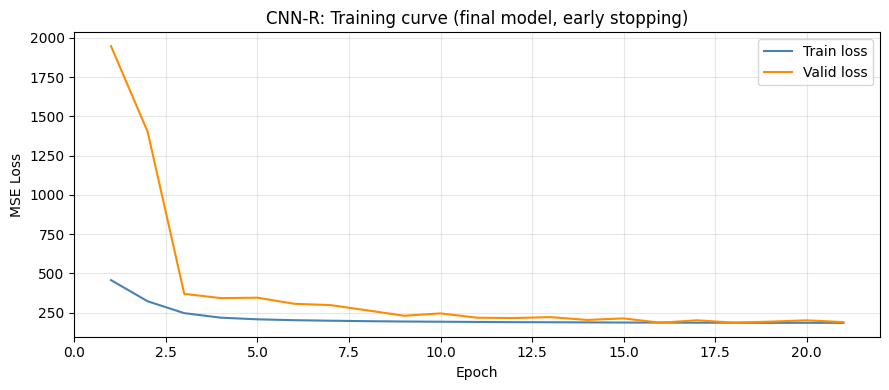

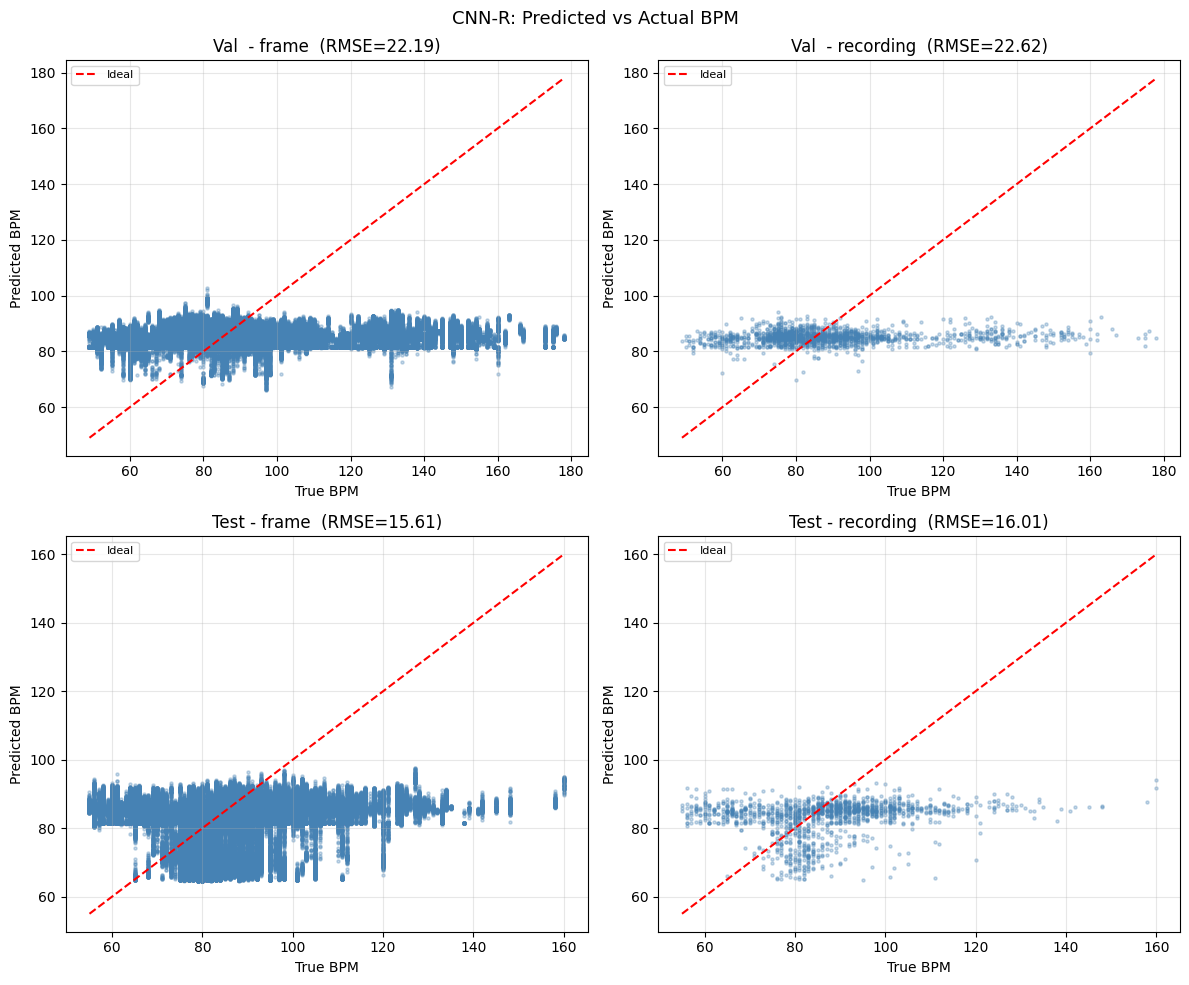

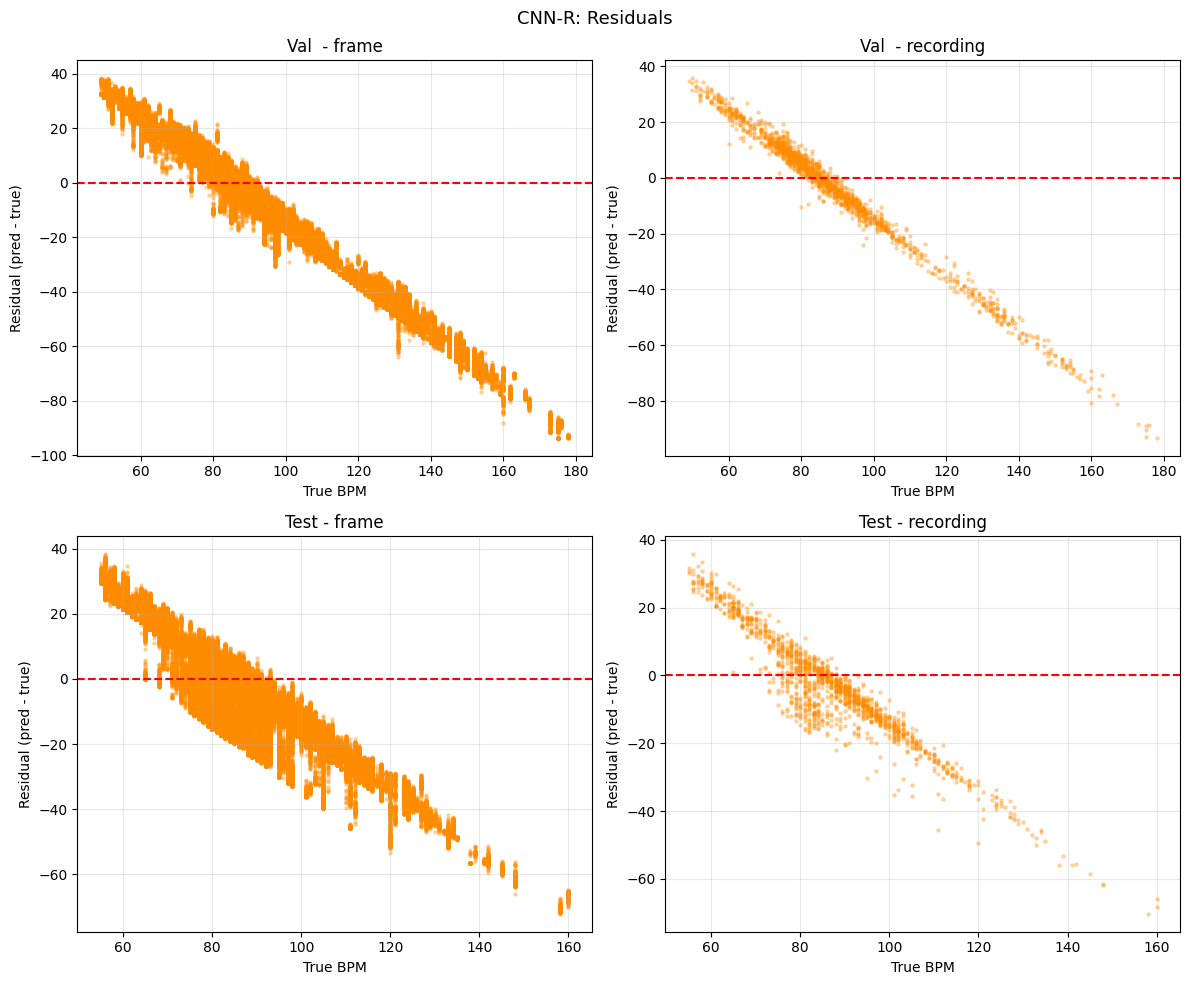

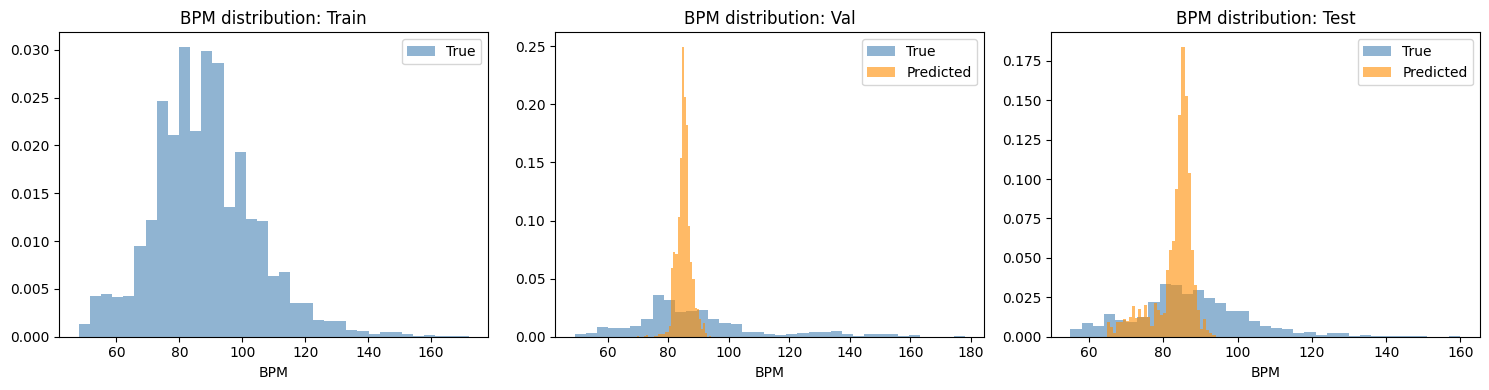

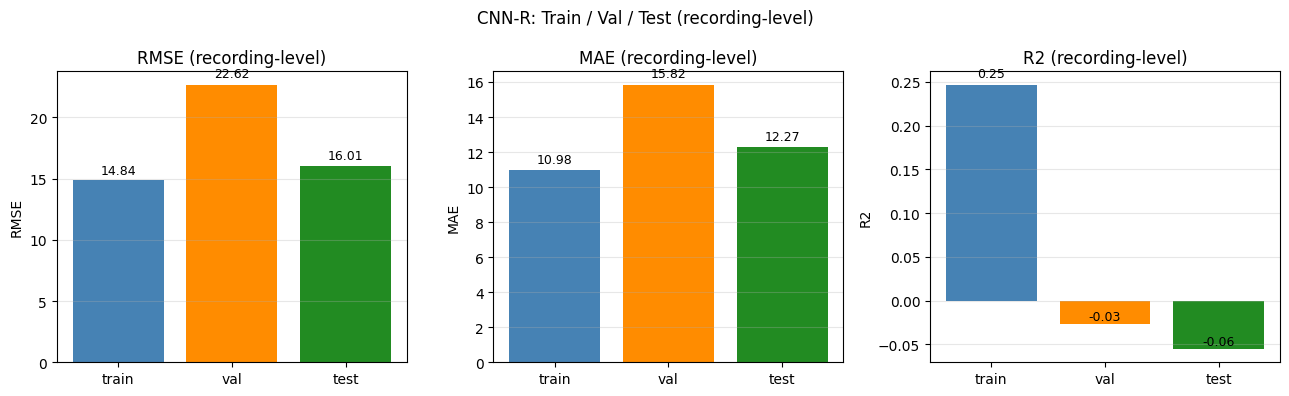

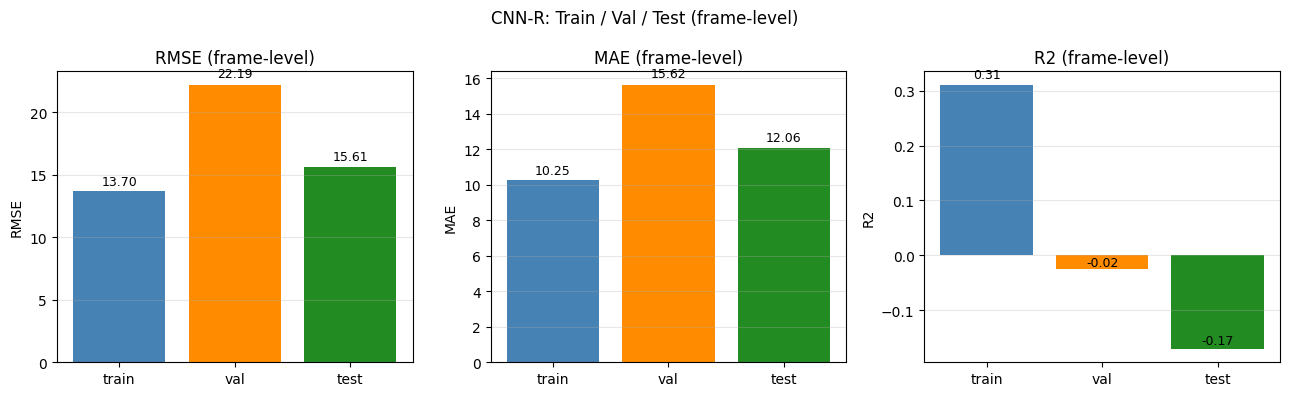

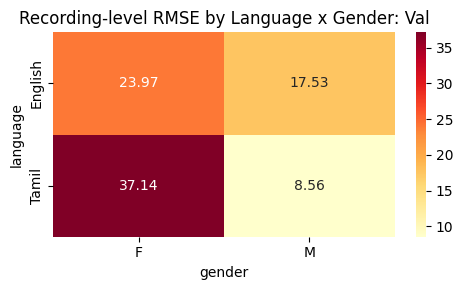

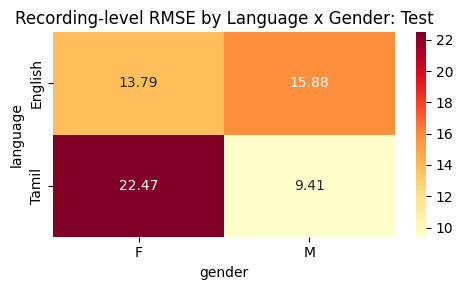

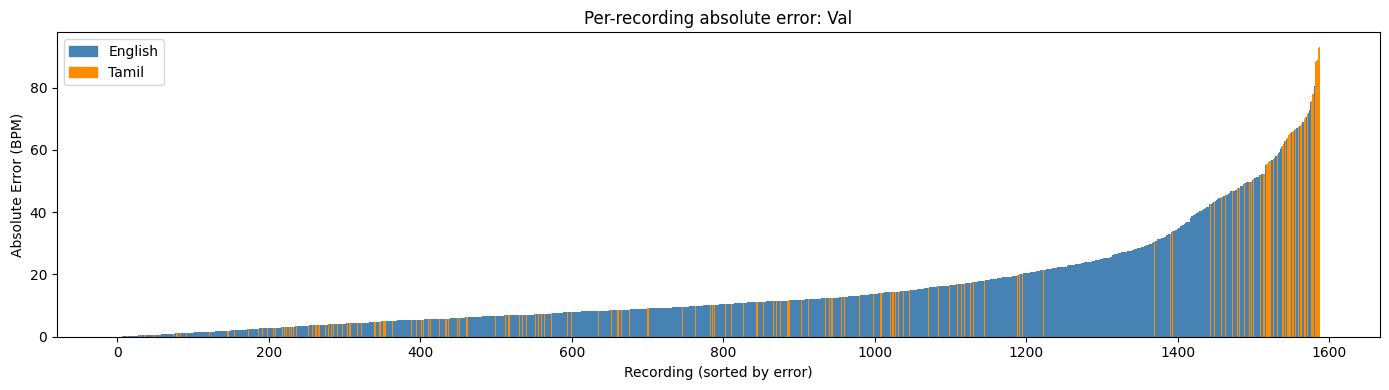

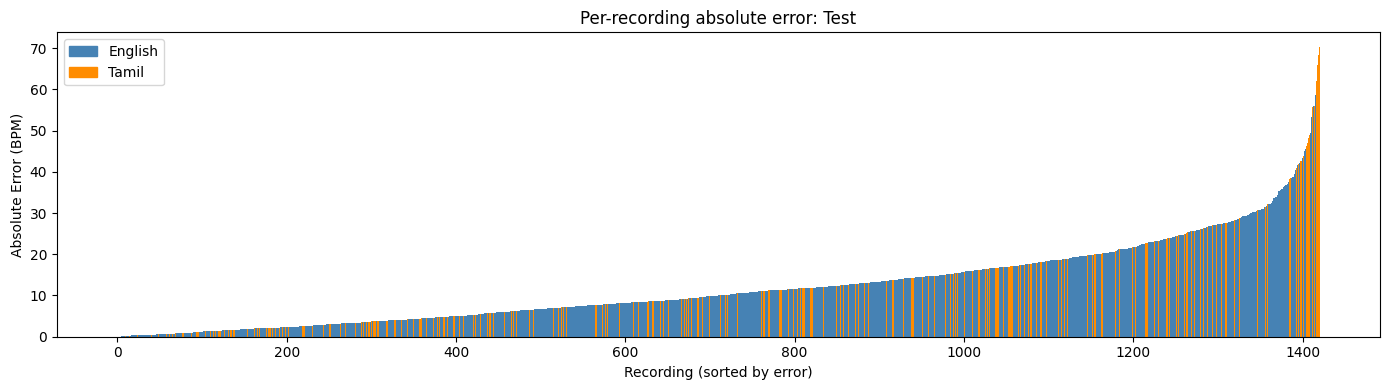

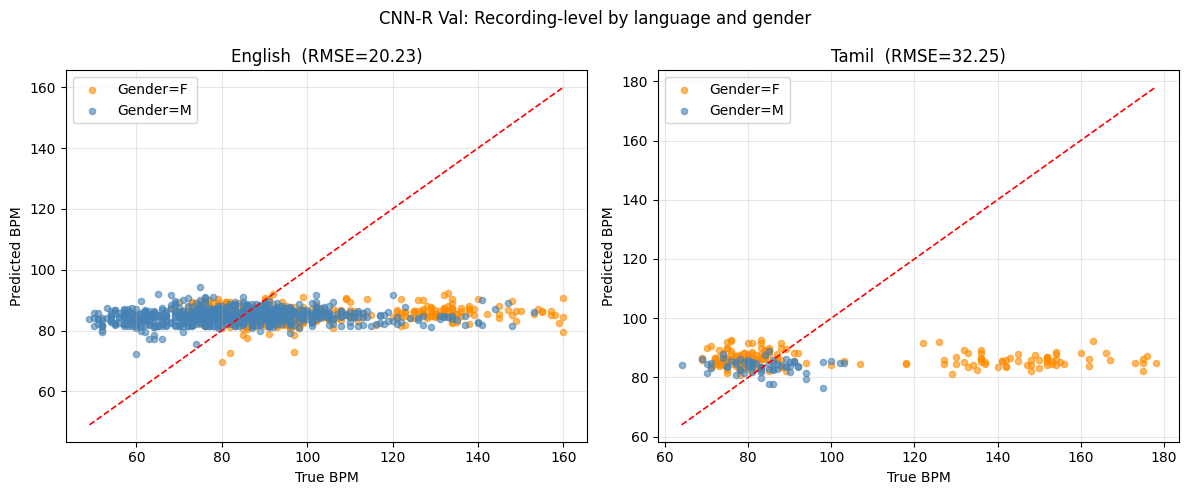

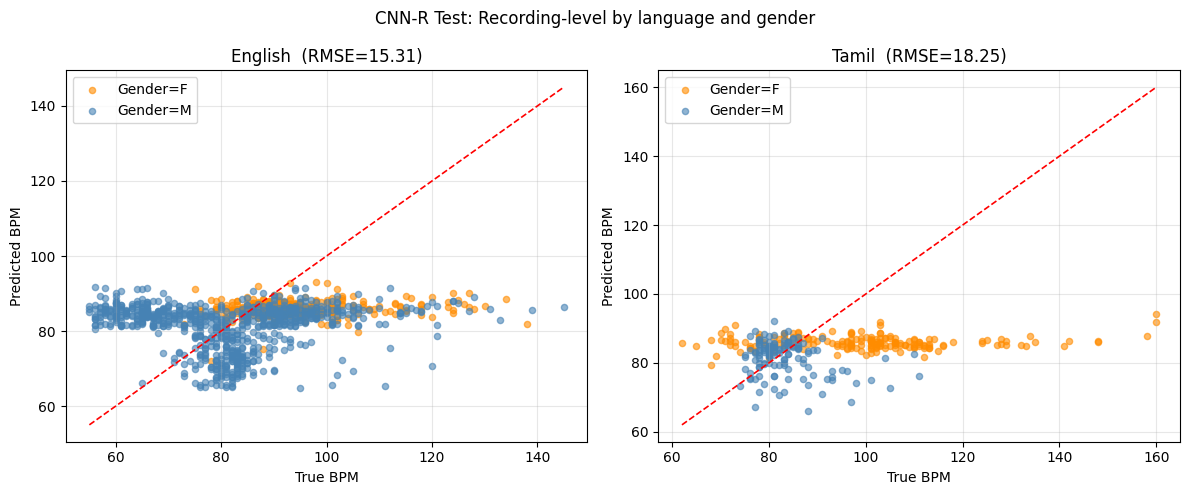

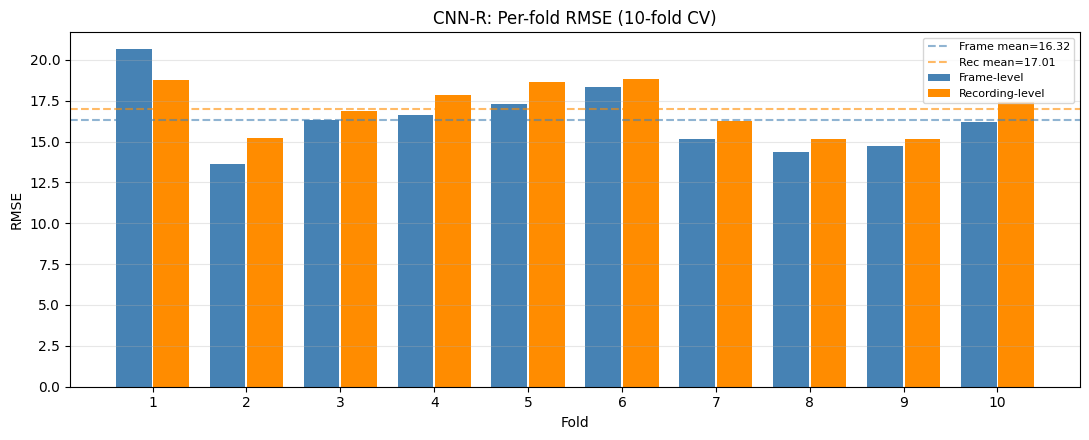

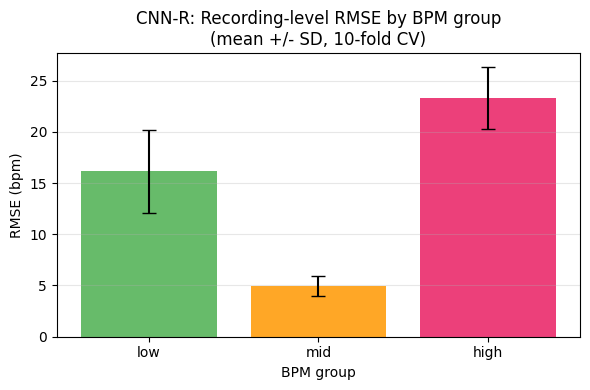


All CNN-R outputs saved to /Users/patrycjamichniewska/Uni/Year 3/Thesis_local/outputs/CNN
  cnn_all_metrics.json
  cnn_best_params.json
  cnn_best_state.pt
  cnn_bpm_distributions.png
  cnn_cv_fold_metrics_frame.csv
  cnn_cv_fold_metrics_recording.csv
  cnn_cv_summary_frame.csv
  cnn_cv_summary_recording.csv
  cnn_perfold_rmse.png
  cnn_residual_plots.png
  cnn_rmse_by_bpm.png
  cnn_scatter_plots.png
  cnn_test_by_lang_gender.png
  cnn_test_heatmap_lang_gender.png
  cnn_test_per_recording_error.png
  cnn_test_recording_predictions.csv
  cnn_train_val_test_rmse_frame.png
  cnn_train_val_test_rmse_recording.png
  cnn_training_curve.png
  cnn_val_by_lang_gender.png
  cnn_val_heatmap_lang_gender.png
  cnn_val_per_recording_error.png
  cnn_val_recording_predictions.csv


In [4]:
# =============================================================================
# CNN-R: hyperparameter search + 10-fold CV evaluation + full outputs
#
# Architecture (Ankishan 2019 / Hafemann dual-pooling style):
#   Conv1d(1 -> n_filters, kernel_size) -> ReLU -> BatchNorm1d
#   -> AvgPool1d || MaxPool1d (concat, dim=1) -> 3xFC hidden -> Linear(1) regression
#
# Pipeline:
#   1. RandomizedSearchCV (PredefinedSplit: train X_train, score X_val)
#   2. Refit on full X_train with early stopping (ValidSplit 20%)
#   4. 10-fold StratifiedGroupKFold CV: frame + recording metrics per fold
#   5. Train / Val / Test evaluation
#   6. 14 plots and all CSVs/JSON saved to outputs/CNN/
#
# n_iter=40 rationale: search grid has 3x3x2x3x3x3x3x4x3 = 5832 combinations.
# Full GridSearchCV x 1 PredefinedSplit = 5832 fits — too slow.
# n_iter=40 samples 40 combinations randomly (40 fits via PredefinedSplit).
# =============================================================================
import warnings
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
import torch.nn as nn
from pathlib import Path
from sklearn.model_selection import (
    RandomizedSearchCV, StratifiedGroupKFold, PredefinedSplit
)
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score
from skorch import NeuralNetRegressor
from skorch.callbacks import EarlyStopping
from skorch.dataset import ValidSplit

# --- Configuration -----------------------------------------------------------
# Set DEBUG = True to run the full pipeline on a small sample (~5 min).
# Set DEBUG = False for the full training run.
DEBUG = False

RANDOM_STATE = 42
N_ITER       = 3  if DEBUG else 40
MAX_EPOCHS   = 5  if DEBUG else 50
N_CV_FOLDS   = 3  if DEBUG else 10
PATIENCE     = 5

DATA_DIR = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data")
OUT_DIR  = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/outputs/CNN")
OUT_DIR.mkdir(parents=True, exist_ok=True)

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"
print(f"Using device: {DEVICE}")

# --- Load all three splits ---------------------------------------------------
X_train      = pd.read_parquet(DATA_DIR / "X_train.parquet").reset_index(drop=True)
y_train      = pd.read_parquet(DATA_DIR / "y_train.parquet").squeeze("columns").reset_index(drop=True)
groups_train = pd.read_parquet(DATA_DIR / "groups_train.parquet").reset_index(drop=True)

X_val        = pd.read_parquet(DATA_DIR / "X_val.parquet").reset_index(drop=True)
y_val        = pd.read_parquet(DATA_DIR / "y_val.parquet").squeeze("columns").reset_index(drop=True)
groups_val   = pd.read_parquet(DATA_DIR / "groups_val.parquet").reset_index(drop=True)

X_test       = pd.read_parquet(DATA_DIR / "X_test.parquet").reset_index(drop=True)
y_test       = pd.read_parquet(DATA_DIR / "y_test.parquet").squeeze("columns").reset_index(drop=True)
groups_test  = pd.read_parquet(DATA_DIR / "groups_test.parquet").reset_index(drop=True)

N_FEATURES  = X_train.shape[1]
X_train_np  = X_train.to_numpy(dtype=np.float32)
y_train_1d  = y_train.to_numpy(dtype=np.float32)
X_val_np    = X_val.to_numpy(dtype=np.float32)
y_val_1d    = y_val.to_numpy(dtype=np.float32)
X_test_np   = X_test.to_numpy(dtype=np.float32)
y_test_1d   = y_test.to_numpy(dtype=np.float32)

print(f"Train: {X_train_np.shape}  Val: {X_val_np.shape}  Test: {X_test_np.shape}")
print(f"N_FEATURES: {N_FEATURES}")

# BPM tertile (used for CV stratification and per-BPM reporting)
bpm_tertile = pd.qcut(
    y_train, q=3, labels=["low", "mid", "high"], duplicates="drop"
).astype(str)
groups_train["bpm_tertile"] = bpm_tertile.values
groups_train["cv_stratum"]  = (
    groups_train["language"] + "_" +
    groups_train["gender"]   + "_" +
    groups_train["bpm_tertile"]
)
ROW_TO_BPM_GROUP = bpm_tertile.values   # frame-level, index-aligned with X_train

if DEBUG:
    N_SPK_DEBUG = 8   # speakers per split — keeps >= 3-fold CV viable
    rng = np.random.default_rng(RANDOM_STATE)
    for _name, _X, _y, _g in [
        ("train", X_train, y_train, groups_train),
        ("val",   X_val,   y_val,   groups_val),
        ("test",  X_test,  y_test,  groups_test),
    ]:
        spk = _g["speaker_id"].unique()
        chosen = rng.choice(spk, size=min(N_SPK_DEBUG, len(spk)), replace=False)
        mask = _g["speaker_id"].isin(chosen).values
        if _name == "train":
            X_train      = _X[mask].reset_index(drop=True)
            y_train      = _y[mask].reset_index(drop=True)
            groups_train = _g[mask].reset_index(drop=True)
        elif _name == "val":
            X_val      = _X[mask].reset_index(drop=True)
            y_val      = _y[mask].reset_index(drop=True)
            groups_val = _g[mask].reset_index(drop=True)
        else:
            X_test      = _X[mask].reset_index(drop=True)
            y_test      = _y[mask].reset_index(drop=True)
            groups_test = _g[mask].reset_index(drop=True)
    # Rebuild numpy arrays + BPM tertile after subsampling
    X_train_np  = X_train.to_numpy(dtype=np.float32)
    y_train_1d  = y_train.to_numpy(dtype=np.float32)
    X_val_np    = X_val.to_numpy(dtype=np.float32)
    y_val_1d    = y_val.to_numpy(dtype=np.float32)
    X_test_np   = X_test.to_numpy(dtype=np.float32)
    y_test_1d   = y_test.to_numpy(dtype=np.float32)
    bpm_tertile = pd.qcut(y_train, q=3, labels=["low","mid","high"], duplicates="drop").astype(str)
    groups_train["bpm_tertile"] = bpm_tertile.values
    groups_train["cv_stratum"]  = (
        groups_train["language"] + "_" + groups_train["gender"] + "_" + groups_train["bpm_tertile"]
    )
    ROW_TO_BPM_GROUP = bpm_tertile.values
    print(f"DEBUG: train={X_train_np.shape}, val={X_val_np.shape}, test={X_test_np.shape}")


# =============================================================================
# MODEL ARCHITECTURE
# =============================================================================

class CNNRegressor(nn.Module):
    """CNN-R: Conv -> ReLU -> BN -> [AvgPool || MaxPool] -> concat -> 3xFC -> regression."""
    def __init__(
        self,
        n_features=93,
        n_filters=10,
        kernel_size=5,
        pool_size=2,
        fc1_hidden=128,
        fc2_hidden=64,
        fc3_hidden=32,
        dropout=0.3,
    ):
        super().__init__()

        self.conv    = nn.Conv1d(1, n_filters, kernel_size, padding=kernel_size // 2)
        self.act     = nn.ReLU()
        self.bn      = nn.BatchNorm1d(n_filters)
        self.avgpool = nn.AvgPool1d(pool_size)
        self.maxpool = nn.MaxPool1d(pool_size)

        # Compute flat size dynamically — dual-pool + concat doubles channel dim
        with torch.no_grad():
            self.bn.eval()
            dummy = torch.zeros(1, 1, n_features)
            h     = self.bn(self.act(self.conv(dummy)))
            flat  = 2 * int(self.avgpool(h).numel())   # x2: AvgPool + MaxPool concat
            self.bn.train()

        # 3 FC hidden layers + regression output (no dropout before final layer)
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(flat, fc1_hidden), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fc1_hidden, fc2_hidden), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fc2_hidden, fc3_hidden), nn.ReLU(),
            nn.Linear(fc3_hidden, 1),
        )

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)                                          # (batch, 1, n_features)
        h = self.bn(self.act(self.conv(x)))                             # (batch, n_filters, L)
        x = torch.cat([self.avgpool(h), self.maxpool(h)], dim=1)       # (batch, 2*n_filters, L//pool)
        return self.fc(x).squeeze(-1)                                   # (batch,)


def make_net(n_features, early_stopping=False):
    callbacks = []
    if early_stopping:
        callbacks.append(
            EarlyStopping(monitor="valid_loss", patience=PATIENCE, lower_is_better=True)
        )
    return NeuralNetRegressor(
        module=CNNRegressor,
        module__n_features=n_features,
        module__n_filters=10,
        module__kernel_size=5,
        module__pool_size=2,
        module__fc1_hidden=128,
        module__fc2_hidden=64,
        module__fc3_hidden=32,
        module__dropout=0.3,
        max_epochs=MAX_EPOCHS,
        criterion=nn.MSELoss,
        optimizer=torch.optim.Adam,
        lr=1e-3,
        batch_size=512,
        device=DEVICE,
        train_split=None,
        verbose=0,
        callbacks=callbacks,
        iterator_train__shuffle=True,
    )

# =============================================================================
# HYPERPARAMETER SEARCH --- PredefinedSplit (train X_train, score X_val)
# =============================================================================

n_train = len(X_train_np)
n_val   = len(X_val_np)

X_search = np.vstack([X_train_np, X_val_np])
y_search = pd.Series(np.concatenate([y_train_1d, y_val_1d]), dtype=np.float32)

ROW_TO_FILE_SEARCH = np.concatenate([
    groups_train["file_name"].values,
    groups_val["file_name"].values,
])

test_fold = np.full(n_train + n_val, -1, dtype=np.int8)
test_fold[n_train:] = 0   # 0 = always in val (scored); -1 = always in train
ps = PredefinedSplit(test_fold)

print(f"\nHyperparameter search: train={n_train:,} frames, score={n_val:,} frames")


def _recording_rmse(y_true, y_pred):
    """Recording-level RMSE scorer for PredefinedSplit (y_true must be pd.Series)."""
    if not isinstance(y_true, pd.Series):
        raise TypeError(f"y_true must be pd.Series (got {type(y_true).__name__})")
    files = ROW_TO_FILE_SEARCH[y_true.index.to_numpy()]
    df = pd.DataFrame({
        "file_name": files,
        "y_true":    y_true.values,
        "y_pred":    np.asarray(y_pred).ravel(),
    })
    rec = df.groupby("file_name").agg(y_true=("y_true", "mean"), y_pred=("y_pred", "mean"))
    return -float(np.sqrt(mean_squared_error(rec["y_true"], rec["y_pred"])))


recording_rmse_scorer = make_scorer(_recording_rmse, greater_is_better=True)

# --- Single-stage random search ---------------------------------------------
search_distributions = {
    "module__n_filters":   [8, 10, 16],
    "module__kernel_size": [3, 5, 7],
    "module__pool_size":   [2, 4],
    "module__fc1_hidden":  [64, 128, 256],
    "module__fc2_hidden":  [32, 64, 128],
    "module__fc3_hidden":  [16, 32, 64],
    "module__dropout":     [0.1, 0.3, 0.5],
    "lr":                  [1e-4, 5e-4, 1e-3, 5e-3],
    "batch_size":          [256, 512, 1024],
}

random_search = RandomizedSearchCV(
    estimator=make_net(N_FEATURES, early_stopping=False),
    param_distributions=search_distributions,
    n_iter=N_ITER,
    scoring=recording_rmse_scorer,
    cv=ps,
    n_jobs=1,
    verbose=2,
    random_state=RANDOM_STATE,
    refit=False,
)
random_search.fit(X_search, y_search)
best_params = random_search.best_params_
print(f"\nBest recording-RMSE (X_val): {-random_search.best_score_:.3f}")
print(f"Best params: {best_params}")

# --- Stage 3: Refit on full X_train with early stopping ---------------------
best_net = make_net(N_FEATURES, early_stopping=True)
best_net.set_params(train_split=ValidSplit(0.2, random_state=RANDOM_STATE))
best_net.set_params(**best_params)
best_net.fit(X_train_np, y_train_1d)

n_epochs      = len(best_net.history_)
best_val_loss = min(ep.get("valid_loss", float("inf")) for ep in best_net.history_)
print(f"\nFinal model: {n_epochs} epochs trained, best_valid_loss={best_val_loss:.4f}")

torch.save(best_net.module_.state_dict(), OUT_DIR / "cnn_best_state.pt")
with open(OUT_DIR / "cnn_best_params.json", "w") as fh:
    json.dump(best_params, fh, indent=2, default=str)
print(f"Saved -> {OUT_DIR / 'cnn_best_params.json'}")
print(f"Saved -> {OUT_DIR / 'cnn_best_state.pt'}")

# =============================================================================
# HELPER FUNCTIONS  (mirrors XGBoost evaluation cell)
# =============================================================================

def compute_metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    if len(y_true) < 2:
        return {"n": int(len(y_true)), "RMSE": float("nan"), "MAE": float("nan"), "R2": float("nan")}
    return {
        "n":    int(len(y_true)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE":  float(mean_absolute_error(y_true, y_pred)),
        "R2":   float(r2_score(y_true, y_pred)),
    }


def aggregate_to_recording(df_frame):
    return (
        df_frame.groupby("file_name")
        .agg(y_true=("y_true", "mean"), y_pred=("y_pred", "mean"),
             language=("language", "first"), gender=("gender", "first"))
        .reset_index()
    )


def make_predictions_df(net, X_np, y_1d, groups_df):
    return pd.DataFrame({
        "file_name": groups_df["file_name"].values,
        "language":  groups_df["language"].values,
        "gender":    groups_df["gender"].values,
        "y_true":    np.asarray(y_1d, float),
        "y_pred":    net.predict(X_np).ravel(),
    })


def full_metrics_block(df_frame, tag):
    df_rec = aggregate_to_recording(df_frame)
    out = {}
    for lvl, df in [("frame", df_frame), ("recording", df_rec)]:
        key = f"{tag}_{lvl}"
        out[key] = {"overall": compute_metrics(df["y_true"], df["y_pred"])}
        for col in ["language", "gender"]:
            out[key][col] = {
                str(g): compute_metrics(sub["y_true"], sub["y_pred"])
                for g, sub in df.groupby(col)
            }
    return out, df_rec


def print_comparison_table(all_metrics):
    for split in ["train", "val", "test"]:
        print(f"\n--- {split.upper()} ---")
        for lvl in ["frame", "recording"]:
            key = f"{split}_{lvl}"
            if key not in all_metrics:
                continue
            m = all_metrics[key]["overall"]
            print(f"  {lvl:10s}: RMSE={m['RMSE']:.3f}  MAE={m['MAE']:.3f}  R2={m['R2']:.3f}  n={m['n']}")
            for col in ["language", "gender"]:
                for grp, gm in sorted(all_metrics[key].get(col, {}).items()):
                    print(f"    {col}={grp:8s}: RMSE={gm['RMSE']:.3f}  MAE={gm['MAE']:.3f}  n={gm['n']}")


def summarise_cv(df):
    return (
        df.groupby(["subgroup", "level"])[["RMSE", "MAE", "R2"]]
        .agg(["mean", "std"])
        .round(3)
    )

# --- Plot helpers ------------------------------------------------------------

def plot_scatter(y_true, y_pred, title, ax):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    ax.scatter(y_true, y_pred, alpha=0.3, s=5, color="steelblue", rasterized=True)
    lo, hi = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], "r--", lw=1.5, label="Ideal")
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    ax.set_xlabel("True BPM"); ax.set_ylabel("Predicted BPM")
    ax.set_title(f"{title}  (RMSE={rmse:.2f})")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)


def plot_residuals(y_true, y_pred, title, ax):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    ax.scatter(y_true, y_pred - y_true, alpha=0.3, s=5, color="darkorange", rasterized=True)
    ax.axhline(0, color="red", lw=1.5, linestyle="--")
    ax.set_xlabel("True BPM"); ax.set_ylabel("Residual (pred - true)")
    ax.set_title(title); ax.grid(alpha=0.3)


def plot_fold_rmse(fold_frame_df, fold_record_df, out_path):
    f = fold_frame_df[fold_frame_df["subgroup"] == "overall"].sort_values("fold")
    r = fold_record_df[fold_record_df["subgroup"] == "overall"].sort_values("fold")
    x = np.arange(len(f))
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.bar(x - 0.2, f["RMSE"], width=0.38, label="Frame-level",     color="steelblue")
    ax.bar(x + 0.2, r["RMSE"], width=0.38, label="Recording-level", color="darkorange")
    ax.axhline(f["RMSE"].mean(), color="steelblue",  lw=1.5, ls="--", alpha=0.6,
               label=f"Frame mean={f['RMSE'].mean():.2f}")
    ax.axhline(r["RMSE"].mean(), color="darkorange", lw=1.5, ls="--", alpha=0.6,
               label=f"Rec mean={r['RMSE'].mean():.2f}")
    ax.set_xticks(x); ax.set_xticklabels(f["fold"].astype(int))
    ax.set_xlabel("Fold"); ax.set_ylabel("RMSE")
    ax.set_title("CNN-R: Per-fold RMSE (10-fold CV)")
    ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
    fig.tight_layout(); fig.savefig(out_path, dpi=200); plt.show(); plt.close(fig)


def plot_bpm_distributions(y_train_true, y_val_true, y_val_pred,
                            y_test_true, y_test_pred, out_path):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, true, pred, split in zip(
        axes,
        [y_train_true, y_val_true,  y_test_true],
        [None,         y_val_pred,  y_test_pred],
        ["Train",      "Val",       "Test"],
    ):
        ax.hist(true, bins=35, alpha=0.6, label="True",      color="steelblue",  density=True)
        if pred is not None:
            ax.hist(pred, bins=35, alpha=0.6, label="Predicted", color="darkorange", density=True)
        ax.set_title(f"BPM distribution: {split}")
        ax.set_xlabel("BPM"); ax.legend()
    fig.tight_layout(); fig.savefig(out_path, dpi=200); plt.show(); plt.close(fig)


def plot_train_val_test_comparison(all_metrics, level, out_path):
    splits = ["train", "val", "test"]
    colors = ["steelblue", "darkorange", "forestgreen"]
    rmse_v = [all_metrics[f"{s}_{level}"]["overall"]["RMSE"] for s in splits]
    mae_v  = [all_metrics[f"{s}_{level}"]["overall"]["MAE"]  for s in splits]
    r2_v   = [all_metrics[f"{s}_{level}"]["overall"]["R2"]   for s in splits]
    x = np.arange(len(splits))
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    for ax, vals, name in zip(axes, [rmse_v, mae_v, r2_v], ["RMSE", "MAE", "R2"]):
        ax.bar(x, vals, color=colors)
        ax.set_xticks(x); ax.set_xticklabels(splits)
        ax.set_ylabel(name); ax.set_title(f"{name} ({level}-level)")
        ax.grid(axis="y", alpha=0.3)
        for i, v in enumerate(vals):
            offset = abs(v) * 0.02 if abs(v) > 0.01 else 0.005
            ax.text(i, v + offset, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
    fig.suptitle(f"CNN-R: Train / Val / Test ({level}-level)", fontsize=12)
    fig.tight_layout(); fig.savefig(out_path, dpi=200); plt.show(); plt.close(fig)


def plot_confusion_by_subgroup(df_rec, tag, out_path):
    rows = [
        {"language": lang, "gender": gen,
         "RMSE": compute_metrics(sub["y_true"].values, sub["y_pred"].values)["RMSE"]}
        for (lang, gen), sub in df_rec.groupby(["language", "gender"])
    ]
    pivot = pd.DataFrame(rows).pivot(index="language", columns="gender", values="RMSE")
    fig, ax = plt.subplots(figsize=(5, 3))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax)
    ax.set_title(f"Recording-level RMSE by Language x Gender: {tag}")
    fig.tight_layout(); fig.savefig(out_path, dpi=200); plt.show(); plt.close(fig)


def inspect_per_recording(df_rec, tag, out_path):
    df = df_rec.copy()
    df["abs_error"] = (df["y_pred"] - df["y_true"]).abs()
    df_s = df.sort_values("abs_error").reset_index(drop=True)
    color_map = {"English": "steelblue", "Tamil": "darkorange"}
    colors = df_s["language"].map(color_map).fillna("grey")
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.bar(np.arange(len(df_s)), df_s["abs_error"], color=colors, width=1.0)
    ax.set_xlabel("Recording (sorted by error)"); ax.set_ylabel("Absolute Error (BPM)")
    ax.set_title(f"Per-recording absolute error: {tag}")
    handles = [mpatches.Patch(color=c, label=l) for l, c in color_map.items()]
    ax.legend(handles=handles)
    fig.tight_layout(); fig.savefig(out_path, dpi=200); plt.show(); plt.close(fig)


def plot_by_lang_gender(df_rec, tag, out_path):
    langs = sorted(df_rec["language"].unique())
    fig, axes = plt.subplots(1, len(langs), figsize=(6 * len(langs), 5))
    if len(langs) == 1:
        axes = [axes]
    gender_colors = {"M": "steelblue", "F": "darkorange"}
    for ax, lang in zip(axes, langs):
        sub = df_rec[df_rec["language"] == lang]
        for gen, g in sub.groupby("gender"):
            ax.scatter(g["y_true"], g["y_pred"], alpha=0.6, s=20,
                       color=gender_colors.get(gen, "grey"), label=f"Gender={gen}")
        lo = min(sub["y_true"].min(), sub["y_pred"].min())
        hi = max(sub["y_true"].max(), sub["y_pred"].max())
        ax.plot([lo, hi], [lo, hi], "r--", lw=1.2)
        rmse = np.sqrt(mean_squared_error(sub["y_true"], sub["y_pred"]))
        ax.set_title(f"{lang}  (RMSE={rmse:.2f})")
        ax.set_xlabel("True BPM"); ax.set_ylabel("Predicted BPM")
        ax.legend(); ax.grid(alpha=0.3)
    fig.suptitle(f"CNN-R {tag}: Recording-level by language and gender")
    fig.tight_layout(); fig.savefig(out_path, dpi=200); plt.show(); plt.close(fig)

# =============================================================================
# EVALUATION: TRAIN / VAL / TEST
# =============================================================================

df_train_frame = make_predictions_df(best_net, X_train_np, y_train_1d, groups_train)
df_val_frame   = make_predictions_df(best_net, X_val_np,   y_val_1d,   groups_val)
df_test_frame  = make_predictions_df(best_net, X_test_np,  y_test_1d,  groups_test)

train_results, train_rec = full_metrics_block(df_train_frame, "train")
val_results,   val_rec   = full_metrics_block(df_val_frame,   "val")
test_results,  test_rec  = full_metrics_block(df_test_frame,  "test")
all_metrics = {**train_results, **val_results, **test_results}

print("\n=== CNN-R performance summary ===")
print_comparison_table(all_metrics)

# =============================================================================
# 10-FOLD CV EVALUATION
# =============================================================================

sgkf_cv = StratifiedGroupKFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_splits_eval = list(sgkf_cv.split(
    X_train_np,
    y=groups_train["cv_stratum"].values,
    groups=groups_train["speaker_id"].values,
))

fold_frame_rows  = []
fold_record_rows = []

print(f"\n=== 10-fold CV evaluation (best architecture) ===")
print(f"{'Fold':>4} | {'Frame RMSE':>10} {'Frame MAE':>9} | {'Rec RMSE':>9} {'Rec MAE':>8} {'n_rec':>6}")
print("-" * 60)

for fold_idx, (tr_idx, va_idx) in enumerate(cv_splits_eval, start=1):
    X_tr  = X_train_np[tr_idx]
    y_tr  = y_train_1d[tr_idx]
    X_va  = X_train_np[va_idx]
    y_va  = y_train_1d[va_idx]
    meta_va  = groups_train.iloc[va_idx].reset_index(drop=True)
    bpm_va   = ROW_TO_BPM_GROUP[va_idx]

    fold_net = make_net(N_FEATURES, early_stopping=False)
    fold_net.set_params(**best_params)
    fold_net.fit(X_tr, y_tr)
    y_pred_fold = fold_net.predict(X_va).ravel()

    # Frame-level metrics
    mf = compute_metrics(y_va, y_pred_fold)
    fold_frame_rows.append({"fold": fold_idx, "subgroup": "overall", "level": "all", **mf})
    for col in ["language", "gender"]:
        for grp, sub_idx in meta_va.groupby(col).groups.items():
            sidx = np.asarray(sub_idx)
            fold_frame_rows.append({
                "fold": fold_idx, "subgroup": col, "level": str(grp),
                **compute_metrics(y_va[sidx], y_pred_fold[sidx]),
            })
    for grp in np.unique(bpm_va):
        mask = (bpm_va == grp)
        fold_frame_rows.append({
            "fold": fold_idx, "subgroup": "bpm_tertile", "level": str(grp),
            **compute_metrics(y_va[mask], y_pred_fold[mask]),
        })

    # Recording-level metrics
    fold_frame_tmp = pd.DataFrame({
        "file_name": meta_va["file_name"].values,
        "language":  meta_va["language"].values,
        "gender":    meta_va["gender"].values,
        "y_true":    y_va,
        "y_pred":    y_pred_fold,
    })
    rec = aggregate_to_recording(fold_frame_tmp)
    mr  = compute_metrics(rec["y_true"].values, rec["y_pred"].values)
    fold_record_rows.append({"fold": fold_idx, "subgroup": "overall", "level": "all", **mr})
    for col in ["language", "gender"]:
        for grp, sub_df in rec.groupby(col):
            fold_record_rows.append({
                "fold": fold_idx, "subgroup": col, "level": str(grp),
                **compute_metrics(sub_df["y_true"].values, sub_df["y_pred"].values),
            })
    # BPM group at recording level
    file_to_bpm = (
        pd.DataFrame({"file_name": meta_va["file_name"].values, "bpm_grp": bpm_va})
        .groupby("file_name")["bpm_grp"].first()
    )
    rec["bpm_grp"] = rec["file_name"].map(file_to_bpm)
    for grp, sub_df in rec.groupby("bpm_grp"):
        fold_record_rows.append({
            "fold": fold_idx, "subgroup": "bpm_tertile", "level": str(grp),
            **compute_metrics(sub_df["y_true"].values, sub_df["y_pred"].values),
        })

    print(f"{fold_idx:>4} | {mf['RMSE']:>10.3f} {mf['MAE']:>9.3f} | "
          f"{mr['RMSE']:>9.3f} {mr['MAE']:>8.3f} {mr['n']:>6}")

fold_frame_df  = pd.DataFrame(fold_frame_rows)
fold_record_df = pd.DataFrame(fold_record_rows)

print("\n=== Frame-level CV summary (mean +/- std, 10 folds) ===")
print(summarise_cv(fold_frame_df))
print("\n=== Recording-level CV summary (mean +/- std, 10 folds) ===")
print(summarise_cv(fold_record_df))

# =============================================================================
# PLOTS
# =============================================================================

# 1. Training loss curve (CNN-specific)
fig, ax = plt.subplots(figsize=(9, 4))
epochs     = [ep["epoch"]                        for ep in best_net.history_]
train_loss = [ep["train_loss"]                   for ep in best_net.history_]
valid_loss = [ep.get("valid_loss", float("nan")) for ep in best_net.history_]
ax.plot(epochs, train_loss, label="Train loss", color="steelblue")
ax.plot(epochs, valid_loss, label="Valid loss", color="darkorange")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
ax.set_title("CNN-R: Training curve (final model, early stopping)")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(OUT_DIR / "cnn_training_curve.png", dpi=200); plt.show(); plt.close(fig)

# 2. Scatter 2x2: val frame | val recording | test frame | test recording
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plot_scatter(df_val_frame["y_true"],  df_val_frame["y_pred"],  "Val  - frame",      axes[0, 0])
plot_scatter(val_rec["y_true"],       val_rec["y_pred"],        "Val  - recording",  axes[0, 1])
plot_scatter(df_test_frame["y_true"], df_test_frame["y_pred"], "Test - frame",      axes[1, 0])
plot_scatter(test_rec["y_true"],      test_rec["y_pred"],       "Test - recording",  axes[1, 1])
fig.suptitle("CNN-R: Predicted vs Actual BPM", fontsize=13)
fig.tight_layout(); fig.savefig(OUT_DIR / "cnn_scatter_plots.png", dpi=200); plt.show(); plt.close(fig)

# 3. Residuals 2x2
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plot_residuals(df_val_frame["y_true"],  df_val_frame["y_pred"],  "Val  - frame",      axes[0, 0])
plot_residuals(val_rec["y_true"],       val_rec["y_pred"],        "Val  - recording",  axes[0, 1])
plot_residuals(df_test_frame["y_true"], df_test_frame["y_pred"], "Test - frame",      axes[1, 0])
plot_residuals(test_rec["y_true"],      test_rec["y_pred"],       "Test - recording",  axes[1, 1])
fig.suptitle("CNN-R: Residuals", fontsize=13)
fig.tight_layout(); fig.savefig(OUT_DIR / "cnn_residual_plots.png", dpi=200); plt.show(); plt.close(fig)

# 4. BPM distributions (recording-level true vs predicted)
plot_bpm_distributions(
    y_train_1d,
    val_rec["y_true"].values,  val_rec["y_pred"].values,
    test_rec["y_true"].values, test_rec["y_pred"].values,
    OUT_DIR / "cnn_bpm_distributions.png",
)

# 5-6. Train/val/test RMSE/MAE/R2 bar grid
plot_train_val_test_comparison(all_metrics, "recording", OUT_DIR / "cnn_train_val_test_rmse_recording.png")
plot_train_val_test_comparison(all_metrics, "frame",     OUT_DIR / "cnn_train_val_test_rmse_frame.png")

# 7-8. Language x gender RMSE heatmaps
plot_confusion_by_subgroup(val_rec,  "Val",  OUT_DIR / "cnn_val_heatmap_lang_gender.png")
plot_confusion_by_subgroup(test_rec, "Test", OUT_DIR / "cnn_test_heatmap_lang_gender.png")

# 9-10. Per-recording sorted absolute error bars
inspect_per_recording(val_rec,  "Val",  OUT_DIR / "cnn_val_per_recording_error.png")
inspect_per_recording(test_rec, "Test", OUT_DIR / "cnn_test_per_recording_error.png")

# 11-12. Scatter coloured by language and gender
plot_by_lang_gender(val_rec,  "Val",  OUT_DIR / "cnn_val_by_lang_gender.png")
plot_by_lang_gender(test_rec, "Test", OUT_DIR / "cnn_test_by_lang_gender.png")

# 13. Per-fold RMSE (frame vs recording side-by-side)
plot_fold_rmse(fold_frame_df, fold_record_df, OUT_DIR / "cnn_perfold_rmse.png")

# 14. RMSE by BPM group (mean +/- SD across 10 CV folds)
bpm_grp_summary = (
    fold_record_df[fold_record_df["subgroup"] == "bpm_tertile"]
    .groupby("level")["RMSE"]
    .agg(["mean", "std"])
    .reindex(["low", "mid", "high"])
    .reset_index()
)
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(bpm_grp_summary["level"], bpm_grp_summary["mean"],
       yerr=bpm_grp_summary["std"], capsize=5,
       color=["#4CAF50", "#FF9800", "#E91E63"], alpha=0.85)
ax.set_xlabel("BPM group"); ax.set_ylabel("RMSE (bpm)")
ax.set_title("CNN-R: Recording-level RMSE by BPM group\n(mean +/- SD, 10-fold CV)")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout(); fig.savefig(OUT_DIR / "cnn_rmse_by_bpm.png", dpi=200); plt.show(); plt.close(fig)

# =============================================================================
# SAVE METRICS AND PREDICTIONS
# =============================================================================

def _jsonify(obj):
    if isinstance(obj, (np.floating, np.integer)):
        return float(obj)
    raise TypeError(f"Not JSON serializable: {type(obj)}")

with open(OUT_DIR / "cnn_all_metrics.json", "w") as fh:
    json.dump(all_metrics, fh, indent=2, default=_jsonify)

val_rec.to_csv(  OUT_DIR / "cnn_val_recording_predictions.csv",  index=False)
test_rec.to_csv( OUT_DIR / "cnn_test_recording_predictions.csv", index=False)
fold_frame_df.to_csv(  OUT_DIR / "cnn_cv_fold_metrics_frame.csv",     index=False)
fold_record_df.to_csv( OUT_DIR / "cnn_cv_fold_metrics_recording.csv", index=False)
summarise_cv(fold_frame_df).to_csv(  OUT_DIR / "cnn_cv_summary_frame.csv")
summarise_cv(fold_record_df).to_csv( OUT_DIR / "cnn_cv_summary_recording.csv")

print(f"\nAll CNN-R outputs saved to {OUT_DIR}")
for p in sorted(OUT_DIR.glob("cnn_*")):
    print(f"  {p.name}")


### Results

The results of ML models training are unsatisfactory and are poorer than the Mean Predictor results. Therefore, an algorithm trained only on the samples of one person will be created, to test the correctness of my pipeline/feasibility of this bpm extraction.

## Single-speaker model

Speakers with >= 120 recordings: 46
 speaker_id  n_recordings
          1           128
          2           125
          3           124
          4           130
          5           128
          6           133
          7           134
          8           127
         17           133
         43           134
         44           134
         52           125
         53           128
         58           128
         59           127
         61           128
         62           133
         63           134
         64           132
         65           133
         66           134
         67           133
         69           128
         71           131
         72           126
         74           128
         75           132
         78           133
         79           134
         81           134
         83           133
         84           128
         86           133
         89           134
         90           134
         91           126
  

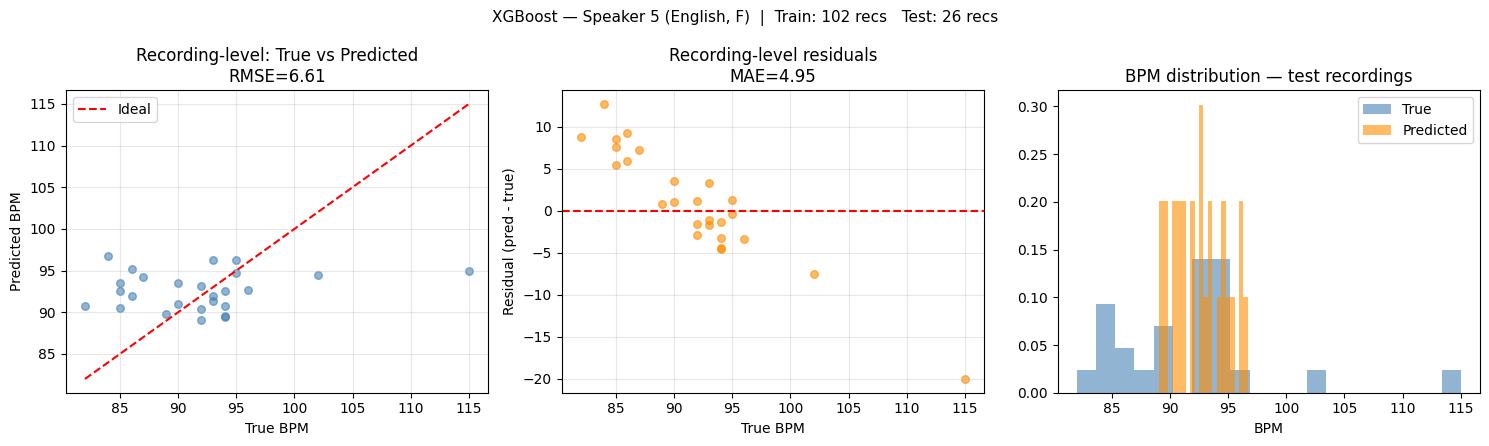

In [1]:
# =============================================================================
# Per-speaker XGBoost: train on one speaker's recordings, predict BPM.
#
# Selects a random speaker with >= 120 recordings, splits their recordings
# 80 / 20 at the recording level (no frame-level leakage), trains XGBoost
# with the best hyperparameters found during the full-dataset search (cell 18),
# and evaluates at both the frame and recording level — reusing the same
# helpers and patterns as the 10-fold CV evaluation (cell 23).
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

RANDOM_STATE    = 42
MIN_RECORDINGS  = 120
TRAIN_FRAC      = 0.80

DATA_DIR = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data")
OUT_DIR  = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Load full normalised dataset (mirrors cell 9) ---------------------------
features = pd.read_parquet(DATA_DIR / "stage_4_normalised.parquet")
metadata = pd.read_csv(DATA_DIR / "tesdhe_metadata.csv")

# Attach speaker_id, language, gender (same merge as cell 9)
features = features.merge(
    metadata[["file_name", "speaker_id", "language", "gender"]],
    on="file_name", how="left",
)

# Feature columns: same DROP_COLS exclusion list as cell 9
DROP_COLS = ["file_name", "frame_idx", "bpm", "speaker_id", "language", "gender"]

# --- Find speakers with >= MIN_RECORDINGS ------------------------------------
recs_per_speaker = (
    features.groupby("speaker_id")["file_name"]
    .nunique()
    .rename("n_recordings")
    .reset_index()
)
eligible = recs_per_speaker[recs_per_speaker["n_recordings"] >= MIN_RECORDINGS].reset_index(drop=True)
print(f"Speakers with >= {MIN_RECORDINGS} recordings: {len(eligible)}")
print(eligible.to_string(index=False))

# Pick one randomly (seeded for reproducibility)
rng = np.random.default_rng(RANDOM_STATE)
chosen_speaker = int(rng.choice(eligible["speaker_id"].values))
n_recs = int(eligible.loc[eligible["speaker_id"] == chosen_speaker, "n_recordings"].iloc[0])

# --- Extract that speaker's data ---------------------------------------------
spk_rows = features[features["speaker_id"] == chosen_speaker].copy().reset_index(drop=True)
spk_lang   = spk_rows["language"].iloc[0]
spk_gender = spk_rows["gender"].iloc[0]

print(f"\nChosen speaker : {chosen_speaker}  ({spk_lang}, {spk_gender})")
print(f"Recordings     : {n_recs}   Frames: {len(spk_rows)}")

# --- Recording-level 80/20 split (same train_test_split call as cell 9) -----
recordings = spk_rows["file_name"].unique().tolist()
train_recs, test_recs = train_test_split(
    recordings,
    test_size=1 - TRAIN_FRAC,
    random_state=RANDOM_STATE,
)
print(f"Train recordings: {len(train_recs)}   Test recordings: {len(test_recs)}")

train_mask = spk_rows["file_name"].isin(train_recs)

X_spk_train = spk_rows.loc[train_mask].drop(columns=DROP_COLS)
y_spk_train = spk_rows.loc[train_mask, "bpm"]
X_spk_test  = spk_rows.loc[~train_mask].drop(columns=DROP_COLS)
y_spk_test  = spk_rows.loc[~train_mask, "bpm"]
meta_test   = spk_rows.loc[~train_mask, "file_name"].reset_index(drop=True)

print(f"Train frames : {len(X_spk_train)}   Test frames : {len(X_spk_test)}")

# --- Load best hyperparameters from cell 18 (falls back to defaults) ---------
best_model_path = OUT_DIR / "xgb_best.json"
if best_model_path.exists():
    _tmp = XGBRegressor()
    _tmp.load_model(best_model_path)
    best_params = {k: v for k, v in _tmp.get_xgb_params().items()
                   if k not in ("n_jobs", "verbosity")}
    best_params["random_state"] = RANDOM_STATE
    print(f"\nLoaded best params from xgb_best.json")
else:
    best_params = dict(
        n_estimators=500, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        min_child_weight=3, reg_alpha=0.1, reg_lambda=5,
        objective="reg:squarederror", tree_method="hist",
        random_state=RANDOM_STATE,
    )
    print(f"\nxgb_best.json not found — using default params")

print(f"Params: {best_params}")

# --- Train (mirrors the per-fold fit in cell 23) -----------------------------
model_spk = XGBRegressor(**best_params)
model_spk.fit(X_spk_train, y_spk_train)

y_pred_test = model_spk.predict(X_spk_test)

# --- Helper functions (mirror cell 23) ---------------------------------------
def compute_metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    if len(y_true) < 2:
        return {"n": int(len(y_true)), "RMSE": np.nan, "MAE": np.nan, "R2": np.nan}
    return {
        "n":    int(len(y_true)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE":  float(mean_absolute_error(y_true, y_pred)),
        "R2":   float(r2_score(y_true, y_pred)),
    }


def aggregate_to_recording(y_true_frames, y_pred_frames, file_names):
    """Average frame-level predictions per recording (mirrors cell 23)."""
    df = pd.DataFrame({
        "file_name": file_names,
        "y_true":    y_true_frames,
        "y_pred":    y_pred_frames,
    })
    return (
        df.groupby("file_name")
        .agg(y_true=("y_true", "mean"), y_pred=("y_pred", "mean"))
        .reset_index()
    )


# --- Metrics at frame and recording level ------------------------------------
m_frame = compute_metrics(y_spk_test.values, y_pred_test)

rec_test = aggregate_to_recording(
    y_spk_test.values, y_pred_test, meta_test.values
)
m_rec = compute_metrics(rec_test["y_true"].values, rec_test["y_pred"].values)

print(f"\n=== Speaker {chosen_speaker} ({spk_lang}, {spk_gender}) — test results ===")
print(f"Frame-level     : RMSE={m_frame['RMSE']:.3f}  MAE={m_frame['MAE']:.3f}  "
      f"R2={m_frame['R2']:.3f}  n={m_frame['n']}")
print(f"Recording-level : RMSE={m_rec['RMSE']:.3f}  MAE={m_rec['MAE']:.3f}  "
      f"R2={m_rec['R2']:.3f}  n={m_rec['n']}")

# Also report training-set fit to inspect overfitting
y_pred_train = model_spk.predict(X_spk_train)
train_recs_df = aggregate_to_recording(
    y_spk_train.values, y_pred_train,
    spk_rows.loc[train_mask, "file_name"].reset_index(drop=True).values,
)
m_train_frame = compute_metrics(y_spk_train.values, y_pred_train)
m_train_rec   = compute_metrics(train_recs_df["y_true"].values, train_recs_df["y_pred"].values)
print(f"\n--- Training set (for overfitting check) ---")
print(f"Frame-level     : RMSE={m_train_frame['RMSE']:.3f}  MAE={m_train_frame['MAE']:.3f}  "
      f"R2={m_train_frame['R2']:.3f}")
print(f"Recording-level : RMSE={m_train_rec['RMSE']:.3f}  MAE={m_train_rec['MAE']:.3f}  "
      f"R2={m_train_rec['R2']:.3f}")

# --- Plots (mirrors cell 23 style) -------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# 1. True vs predicted — recording level
ax = axes[0]
ax.scatter(rec_test["y_true"], rec_test["y_pred"], alpha=0.6, s=30, color="steelblue")
lo = min(rec_test["y_true"].min(), rec_test["y_pred"].min())
hi = max(rec_test["y_true"].max(), rec_test["y_pred"].max())
ax.plot([lo, hi], [lo, hi], "r--", lw=1.5, label="Ideal")
ax.set_xlabel("True BPM")
ax.set_ylabel("Predicted BPM")
ax.set_title(f"Recording-level: True vs Predicted\nRMSE={m_rec['RMSE']:.2f}")
ax.legend()
ax.grid(alpha=0.3)

# 2. Residuals — recording level
ax = axes[1]
ax.scatter(rec_test["y_true"], rec_test["y_pred"] - rec_test["y_true"],
           alpha=0.6, s=30, color="darkorange")
ax.axhline(0, color="red", lw=1.5, linestyle="--")
ax.set_xlabel("True BPM")
ax.set_ylabel("Residual (pred - true)")
ax.set_title(f"Recording-level residuals\nMAE={m_rec['MAE']:.2f}")
ax.grid(alpha=0.3)

# 3. BPM distribution: true vs predicted (recording level)
ax = axes[2]
ax.hist(rec_test["y_true"], bins=20, alpha=0.6, label="True",
        color="steelblue", density=True)
ax.hist(rec_test["y_pred"], bins=20, alpha=0.6, label="Predicted",
        color="darkorange", density=True)
ax.set_xlabel("BPM")
ax.legend()
ax.set_title(f"BPM distribution — test recordings")

fig.suptitle(
    f"XGBoost — Speaker {chosen_speaker} ({spk_lang}, {spk_gender})  |  "
    f"Train: {len(train_recs)} recs   Test: {len(test_recs)} recs",
    fontsize=11,
)
fig.tight_layout()
fig.savefig(OUT_DIR / f"xgb_speaker_{chosen_speaker}.png", dpi=200)
plt.show()
plt.close(fig)


## Model comparison

Both models perform substantially worse than the baseline (mean predictor). 
However, XXX achieved slightly better results with RMSE = 

Due to the poor results achieved, bias mitigation will not be enforced but SHAP will be performed for both models. 

## Interpretability with SHAP

Both models are analysed using SHAP to identify which acoustic features drive BPM predictions.

**XGBoost** — `TreeExplainer` (exact Shapley values, native tree support):
- Global beeswarm summary plot (top 20 features by mean |SHAP|)
- Bar plot of mean |SHAP| per feature (top 20)

**CNN** — `GradientExplainer` (expected gradients, GPU-safe on CPU):
- Global beeswarm summary plot (top 20 features by mean |SHAP|)
- Bar plot of mean |SHAP| per feature (top 20)
- Printed table of top 10 features by mean |SHAP|

### XGBoost

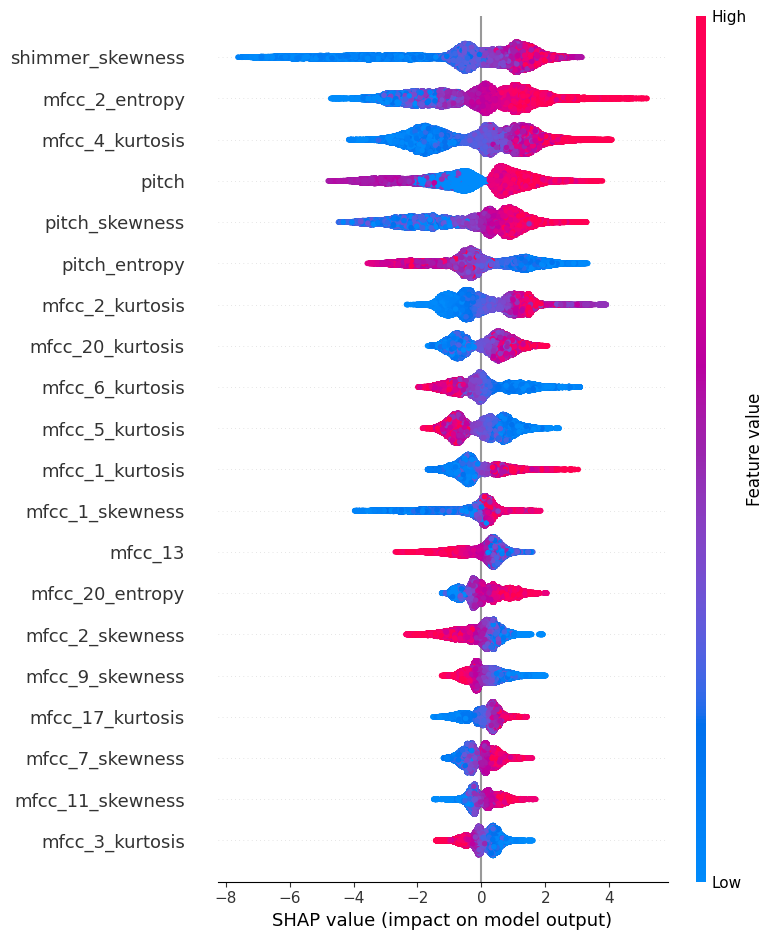

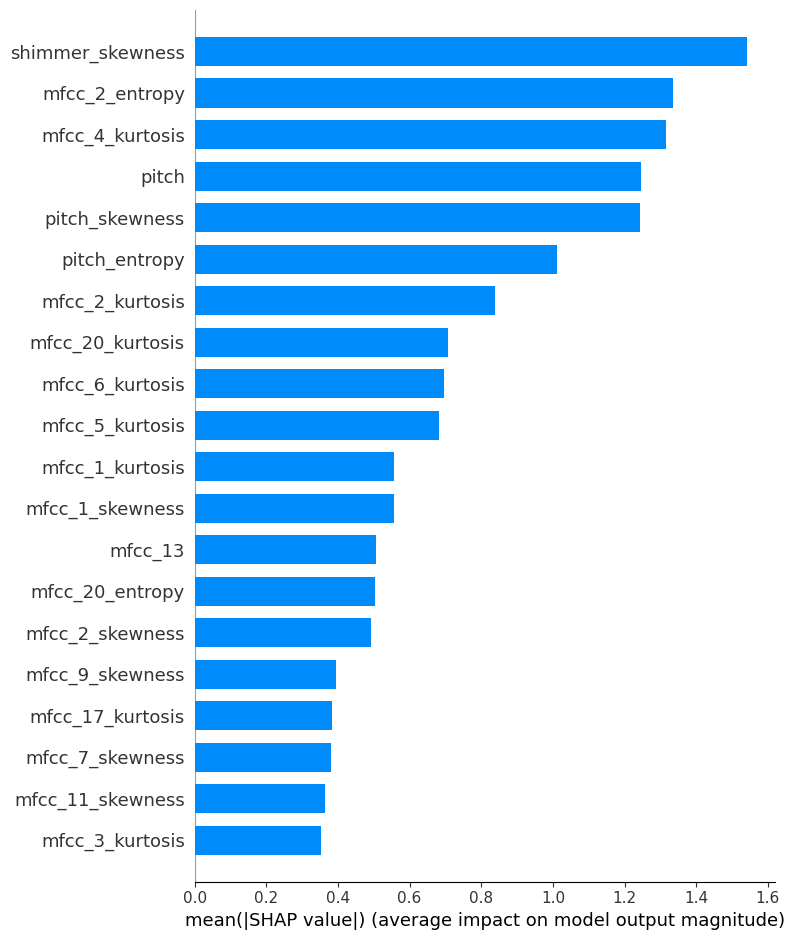

In [1]:

import shap
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from xgboost import XGBRegressor


DATA_DIR = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data")
OUT_DIR  = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/outputs/XGB")

# Load model and test data
model = XGBRegressor()
model.load_model(OUT_DIR / "xgb_best.json")

X_test = pd.read_parquet(DATA_DIR / "X_test.parquet").reset_index(drop=True)

# TreeExplainer 
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)   # shape: (n_frames, n_features)

# Global summary plot — top features by mean |SHAP|
shap.summary_plot(shap_values, X_test, max_display=20, show=False)
plt.tight_layout()
plt.savefig(OUT_DIR / "xgb_shap_summary.png", dpi=200, bbox_inches="tight")
plt.show()

# Bar plot — feature importance by mean |SHAP|
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=20, show=False)
plt.tight_layout()
plt.savefig(OUT_DIR / "xgb_shap_bar.png", dpi=200, bbox_inches="tight")
plt.show()


### CNN

/var/folders/ck/8cqqb5gj2xndyw28s7mysf_00000gn/T/ipykernel_8212/2934740284.py:95: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, test_np, feature_names=feature_names,


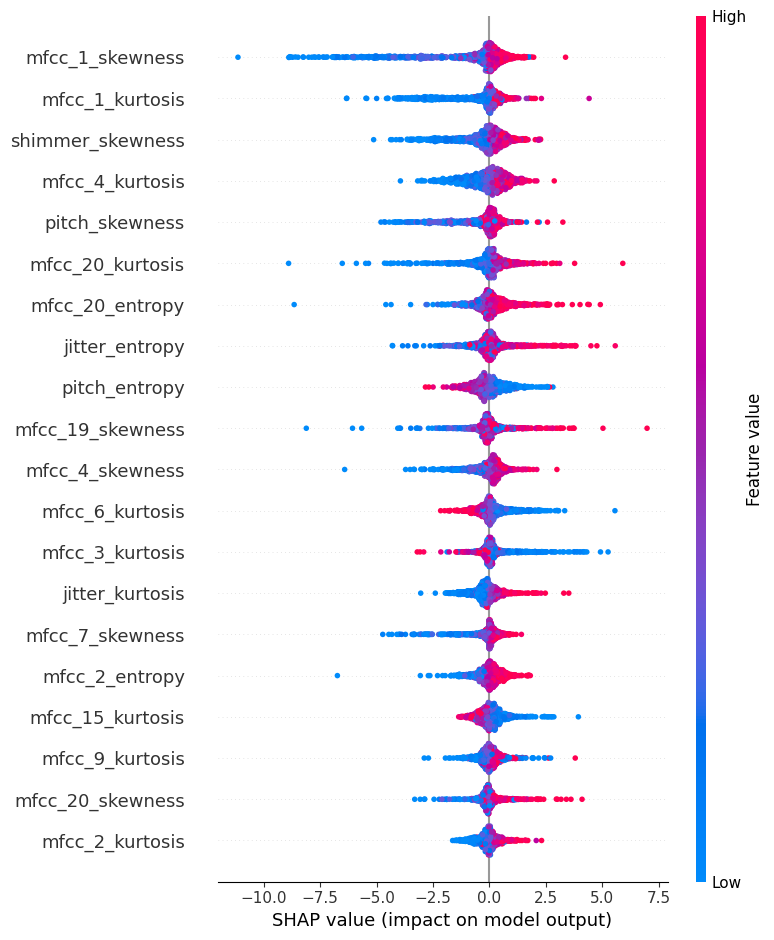

/var/folders/ck/8cqqb5gj2xndyw28s7mysf_00000gn/T/ipykernel_8212/2934740284.py:102: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, test_np, feature_names=feature_names,


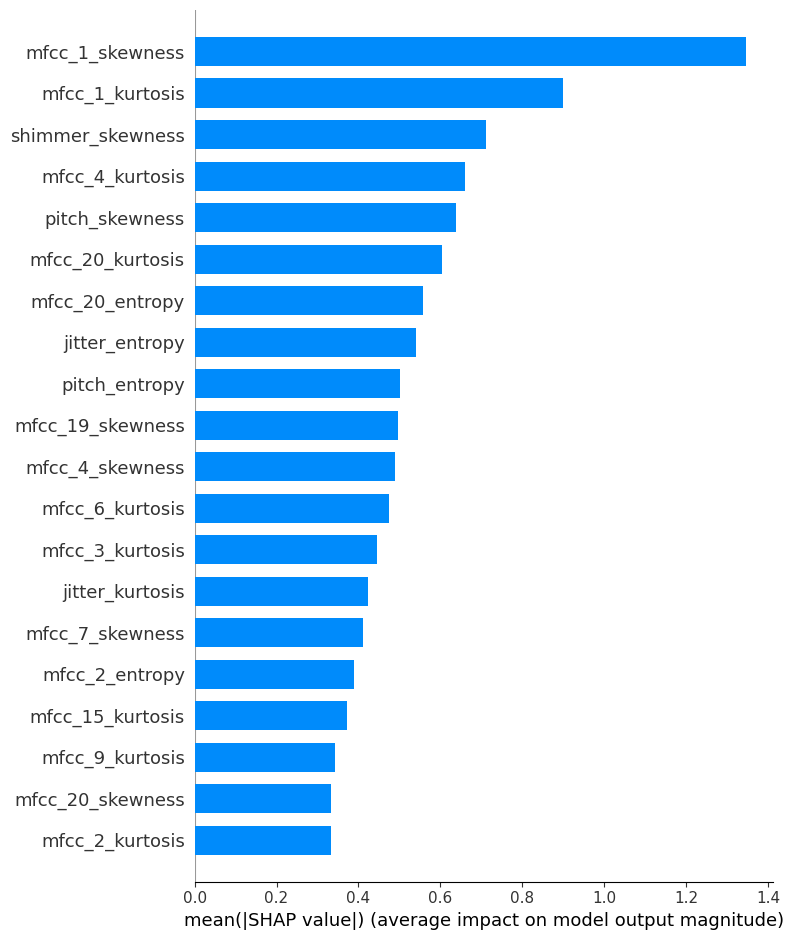


Top 10 features by mean |SHAP|:
mfcc_1_skewness     1.346116
mfcc_1_kurtosis     0.899589
shimmer_skewness    0.710601
mfcc_4_kurtosis     0.661298
pitch_skewness      0.639035
mfcc_20_kurtosis    0.603990
mfcc_20_entropy     0.557129
jitter_entropy      0.541172
pitch_entropy       0.500846
mfcc_19_skewness    0.496936


In [5]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import json
from pathlib import Path

DATA_DIR = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data")
OUT_DIR  = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/outputs/CNN")

# Load saved architecture params
with open(OUT_DIR / "cnn_best_params.json") as f:
    saved_params = json.load(f)

def _cast(v):
    """Convert back to int/float if stored as string (json default=str can stringify numpy scalars)."""
    if isinstance(v, str):
        try: return int(v)
        except ValueError: pass
        try: return float(v)
        except ValueError: pass
    return v

arch_params = {
    k.replace("module__", ""): _cast(v)
    for k, v in saved_params.items()
    if k.startswith("module__") and k != "module__n_features"
}

# Reconstruct architecture — must match cell 20 exactly
class CNNRegressor(nn.Module):
    def __init__(self, n_features, n_filters=10, kernel_size=5, pool_size=2,
                 fc1_hidden=128, fc2_hidden=64, fc3_hidden=32, dropout=0.3):
        super().__init__()
        self.conv    = nn.Conv1d(1, n_filters, kernel_size, padding=kernel_size // 2)
        self.act     = nn.ReLU()
        self.bn      = nn.BatchNorm1d(n_filters)
        self.avgpool = nn.AvgPool1d(pool_size)
        self.maxpool = nn.MaxPool1d(pool_size)
        with torch.no_grad():
            self.bn.eval()
            dummy = torch.zeros(1, 1, n_features)
            h     = self.bn(self.act(self.conv(dummy)))
            flat  = 2 * int(self.avgpool(h).numel())
            self.bn.train()
        self.fc = nn.Sequential(
            nn.Flatten(), nn.Dropout(dropout),
            nn.Linear(flat, fc1_hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(fc1_hidden, fc2_hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(fc2_hidden, fc3_hidden), nn.ReLU(),
            nn.Linear(fc3_hidden, 1),
        )
    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)
        h = self.bn(self.act(self.conv(x)))
        x = torch.cat([self.avgpool(h), self.maxpool(h)], dim=1)
        return self.fc(x).squeeze(-1)

# Load data
X_train_df = pd.read_parquet(DATA_DIR / "X_train.parquet").reset_index(drop=True)
X_test_df  = pd.read_parquet(DATA_DIR / "X_test.parquet").reset_index(drop=True)
N_FEATURES    = X_train_df.shape[1]
feature_names = X_train_df.columns.tolist()

# Load model weights — CPU only (SHAP does not support MPS)
model = CNNRegressor(n_features=N_FEATURES, **arch_params)
model.load_state_dict(torch.load(OUT_DIR / "cnn_best_state.pt", map_location="cpu"))
model.eval()

# Sample — full ~1M frames is too slow for GradientExplainer
rng         = np.random.default_rng(42)
background  = torch.FloatTensor(
    X_train_df.iloc[rng.choice(len(X_train_df), 500, replace=False)].to_numpy(np.float32)
)
test_tensor = torch.FloatTensor(
    X_test_df.iloc[rng.choice(len(X_test_df), 1000, replace=False)].to_numpy(np.float32)
)

# GradientExplainer — uses expected gradients, correct for PyTorch
explainer   = shap.GradientExplainer(model, background)
shap_values = explainer.shap_values(test_tensor)

# Single-output regression: shap_values may be a list with one element
if isinstance(shap_values, list):
    shap_values = shap_values[0]
shap_values = np.asarray(shap_values)   # (n_test, n_features)
test_np     = test_tensor.numpy()

# 1. Beeswarm summary — feature value vs SHAP value
shap.summary_plot(shap_values, test_np, feature_names=feature_names,
                  max_display=20, show=False)
plt.tight_layout()
plt.savefig(OUT_DIR / "cnn_shap_summary.png", dpi=200, bbox_inches="tight")
plt.show()

# 2. Bar plot — mean |SHAP| per feature
shap.summary_plot(shap_values, test_np, feature_names=feature_names,
                  plot_type="bar", max_display=20, show=False)
plt.tight_layout()
plt.savefig(OUT_DIR / "cnn_shap_bar.png", dpi=200, bbox_inches="tight")
plt.show()

# 3. Print top 10
top10 = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_names).nlargest(10)
print("\nTop 10 features by mean |SHAP|:")
print(top10.to_string())
